# 通用神经网络处理器多核调度：瓶颈定位与优化验证

本笔记本执行 `PROMPT_FOR_OPUS5.md` 要求的两件事：**用只读证据定位真实瓶颈**，以及**给出可复现、按 `问题 × 核数` 分档的优化方案**。

约定：
- 唯一评分依据是 `2026_official/code/` 官方评估器；本笔记本中一切代理指标（`_proxy_score`、`_plan_schedule_metrics`、critical path）仅用于候选排序说明，**不作为成绩**。
- 加速比口径固定为：分母 = 官方 `singlecore_evaluate.py` 的 `singlecore_makespan`，**逐用例取比值后再算术平均**，不使用总 makespan 之比。
- `2026_official/` 只读，全流程用哈希基线校验。
- 所有"预期提升"均标注为待验证假设，并附验证命令。

In [8]:
# 环境与只读约束检查
import os, sys, csv, json, shutil, hashlib, subprocess, tempfile, time, statistics as st
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import scipy.stats as sps
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["figure.dpi"] = 110
try:
    plt.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Heiti SC", "Arial Unicode MS"]
    plt.rcParams["axes.unicode_minus"] = False
except Exception:
    pass

ROOT = Path("/Users/macbook/Documents/数学建模 A 题")
OFFICIAL = ROOT / "2026_official"
SOLVER = ROOT / "solver"
RESULT_DIR = ROOT / "results_round5" / "r05-full-unified-summary-20260925"
SUMMARY_CSV = RESULT_DIR / "full_case_core_summary.csv"
CONFIG_PATH = OFFICIAL / "data" / "config.txt"
SANDBOX = ROOT / "results_diag"
SANDBOX.mkdir(parents=True, exist_ok=True)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("python:", sys.version.split()[0])
for label, path in [("SUMMARY_CSV", SUMMARY_CSV), ("CONFIG_PATH", CONFIG_PATH),
                    ("solver/", SOLVER), ("2026_official/code/", OFFICIAL / "code")]:
    print(f"{label:22s} exists={path.exists()}  {path}")


python: 3.9.6
SUMMARY_CSV            exists=True  /Users/macbook/Documents/数学建模 A 题/results_round5/r05-full-unified-summary-20260925/full_case_core_summary.csv
CONFIG_PATH            exists=True  /Users/macbook/Documents/数学建模 A 题/2026_official/data/config.txt
solver/                exists=True  /Users/macbook/Documents/数学建模 A 题/solver
2026_official/code/    exists=True  /Users/macbook/Documents/数学建模 A 题/2026_official/code


In [42]:
# 官方目录哈希基线：正式跑分必须走原目录，任何改动立即暴露
HASH_BASELINE = SANDBOX / "official_hash_baseline.json"

# 官方评估器在未显式关闭时会往计算图同目录写 *_trace.json / *_log.txt。
# 这些是运行产物而非评测代码，纳入校验会持续误报，因此单独排除并记录。
GENERATED_PATTERNS = ("_trace.json", "_log.txt", "_multicore_res.json", ".pyc")


def is_evaluator_artifact(relative: str) -> bool:
    return any(relative.endswith(p) for p in GENERATED_PATTERNS)


def hash_tree(root: Path) -> dict:
    out = {}
    for path in sorted(root.rglob("*")):
        if not path.is_file() or "__pycache__" in path.parts:
            continue
        relative = path.relative_to(root).as_posix()
        if is_evaluator_artifact(relative):
            continue
        out[relative] = hashlib.sha256(path.read_bytes()).hexdigest()
    return out


def assert_official_untouched(*, rebuild: bool = False) -> dict:
    """校验 2026_official/ 的代码与配置未被修改；rebuild=True 时重建基线。"""
    current = hash_tree(OFFICIAL)
    if rebuild or not HASH_BASELINE.is_file():
        HASH_BASELINE.write_text(json.dumps(current, indent=2), encoding="utf-8")
        print(f"基线已写入 {HASH_BASELINE.name}，共 {len(current)} 个受保护文件"
              f"（已排除评估器运行产物）")
        return current
    baseline = json.loads(HASH_BASELINE.read_text(encoding="utf-8"))
    added = sorted(set(current) - set(baseline))
    removed = sorted(set(baseline) - set(current))
    changed = sorted(k for k in set(current) & set(baseline) if current[k] != baseline[k])
    status = "OK" if not (added or removed or changed) else "MODIFIED"
    print(f"assert_official_untouched(): {status}"
          f" | added={len(added)} removed={len(removed)} changed={len(changed)}")
    for name, items in (("added", added), ("removed", removed), ("changed", changed)):
        if items:
            print(f"  {name}: {items[:8]}")
    return baseline


_ = assert_official_untouched(rebuild=True)
print("受保护文件总数:", len(hash_tree(OFFICIAL)))
print("其中官方评估器脚本:", len(list((OFFICIAL / "code").glob("*.py"))))


基线已写入 official_hash_baseline.json，共 114 个受保护文件（已排除评估器运行产物）
受保护文件总数: 114
其中官方评估器脚本: 10


## 第 1 节 · 基线复算：三问题 × 五核加速比逐格核对

数据源：`results_round5/r05-full-unified-summary-20260925/full_case_core_summary.csv`（500 行 = 100 case × 5 ncores）。

复算规则（与 `PROMPT_FOR_OPUS5.md` 第 3 节约束 4 一致）：
- P1 / P2 直接使用 CSV 中的 `p{1,2}_chain_speedup_vs_singlecore` 列；
- P3 该列不存在，按 `singlecore_makespan / p3_chain_makespan` 逐用例重算；
- 所有数值先逐用例取比值，**再对 100 个用例取算术平均**。

In [3]:
df = pd.read_csv(SUMMARY_CSV, encoding="utf-8-sig")
print("行数:", len(df))
dups = df.duplicated(subset=["case", "ncores"]).sum()
print("重复 (case, ncores) 行数:", int(dups))
print("case 数:", df["case"].nunique(), "| ncores 取值:", sorted(df["ncores"].unique()))
print("每 case 的 ncores 计数分布:", dict(Counter(df.groupby("case")["ncores"].size())))

missing_pair = df[df["p3_case_core_pair_complete"] != True]
print("p3_case_core_pair_complete 非 True 行数:", len(missing_pair))

BASELINE_REF = pd.DataFrame(
    [[1.003, 1.495, 1.577, 2.100, 2.100],
     [1.007, 1.718, 2.269, 2.767, 3.128],
     [1.016, 1.735, 2.296, 2.812, 3.173]],
    index=["P1", "P2", "P3"], columns=[1, 2, 3, 4, 5],
)


def speedup_table(frame: pd.DataFrame) -> pd.DataFrame:
    out = {}
    for nc in sorted(frame["ncores"].unique()):
        sel = frame[frame["ncores"] == nc]
        out[nc] = {
            "P1": sel["p1_chain_speedup_vs_singlecore"].mean(),
            "P2": sel["p2_chain_speedup_vs_singlecore"].mean(),
            "P3": (sel["singlecore_makespan"] / sel["p3_chain_makespan"]).mean(),
        }
    return pd.DataFrame(out).T[["P1", "P2", "P3"]].T


recomputed = speedup_table(df)
print("\n== 复算（逐用例比值后算术平均）==")
print(recomputed.round(4))

delta = (recomputed - BASELINE_REF).round(4)
print("\n== 与基线表逐格差值 ==")
print(delta)
print("\n最大绝对偏差:", float(np.abs(delta.values).max()))


行数: 500
重复 (case, ncores) 行数: 0
case 数: 100 | ncores 取值: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
每 case 的 ncores 计数分布: {5: 100}
p3_case_core_pair_complete 非 True 行数: 0

== 复算（逐用例比值后算术平均）==
         1       2       3       4       5
P1  1.0025  1.4950  1.5773  2.1005  2.1005
P2  1.0072  1.7175  2.2686  2.7669  3.1278
P3  1.0156  1.7354  2.2959  2.8123  3.1729

== 与基线表逐格差值 ==
         1       2       3       4       5
P1 -0.0005  0.0000  0.0003  0.0005  0.0005
P2  0.0002 -0.0005 -0.0004 -0.0001 -0.0002
P3 -0.0004  0.0004 -0.0001  0.0003 -0.0001

最大绝对偏差: 0.0005


In [9]:
# P3 双口径：全部用例 vs 仅 p3_case_core_pair_complete == True
p3_all = {nc: float(df[df.ncores == nc].eval("singlecore_makespan / p3_chain_makespan").mean())
          for nc in sorted(df.ncores.unique())}
kept = df[df["p3_case_core_pair_complete"] == True]
p3_kept = {nc: float(kept[kept.ncores == nc].eval("singlecore_makespan / p3_chain_makespan").mean())
           for nc in sorted(df.ncores.unique())}
caliber = pd.DataFrame({"全部用例": p3_all, "仅pair_complete": p3_kept})
caliber["差异"] = caliber["全部用例"] - caliber["仅pair_complete"]
print("== P3 两种口径对比（行 = ncores）==")
print(caliber.round(6))

print("\n== 1 核下 chain 方案 vs 官方单核算法 ==")
one = df[df.ncores == 1]
for prob, col in [("P1", "p1_chain_makespan"), ("P2", "p2_chain_makespan"), ("P3", "p3_chain_makespan")]:
    ratio = (one[col] / one["singlecore_makespan"])
    print(f"{prob}: chain/单核 比值 均值={ratio.mean():.6f} 中位={ratio.median():.6f} "
          f"min={ratio.min():.6f} max={ratio.max():.6f} | 比值>1 的用例={int((ratio > 1).sum())}")
print("\n单核状态:", dict(Counter(df[df.ncores == 1]["singlecore_status"])))

# ---- 内核版本门禁 ----
# solver/ 使用 @dataclass(slots=True)，需要 Python >= 3.10。
# 若当前内核低于 3.10，则所有依赖 solver/ 的单元格改为「用 3.11 子进程执行」。
KERNEL_OK = sys.version_info >= (3, 10)
PY311 = shutil.which("python3.11") or shutil.which("python3")
HELPER = SANDBOX / "run_in_py311.py"


def ensure_helper() -> None:
    """写出一个在 Python 3.11 子进程中执行 solver/ 逻辑的辅助脚本。"""
    if HELPER.is_file():
        return
    HELPER.write_text('''"""在 Python 3.11 下运行求解器侧分析；本机 notebook 内核为 3.9。"""
from __future__ import annotations
import json, sys, argparse
from collections import Counter
from pathlib import Path

ROOT = Path("/Users/macbook/Documents/数学建模 A 题")
sys.path.insert(0, str(ROOT))

from solver.graph_io import load_graph, load_config
from solver.graph_analysis import analyze_graph
from solver.partition import candidate_group_counts
from solver.chain_partition import build_chains, _chain_dag, _chain_topological_order
from solver import schedule_a, schedule_b, cache_aware

MODULES = {1: schedule_a, 2: schedule_b, 3: cache_aware}


def cmd_candidate_counts(args):
    out = []
    for problem in (1, 2, 3):
        for ncores in (1, 2, 3, 4, 5):
            out.append({"problem": problem, "ncores": ncores,
                        "candidates": candidate_group_counts(10000, ncores, problem)})
    return out


def cmd_chain_structure(args):
    out = []
    for case in args.cases:
        graph = load_graph(ROOT / "2026_official" / "data" / f"{case}.json")
        analysis = analyze_graph(graph)
        chains, chain_of_op, edge_bytes = build_chains(analysis)
        succ, pred = _chain_dag(chains, chain_of_op, analysis)
        order = _chain_topological_order(chains, succ, pred)
        level = {}
        for cid in order:
            level[cid] = max([level[p] for p in pred[cid]], default=-1) + 1
        width = Counter(level.values())
        lengths = [len(c.members) for c in chains]
        out.append({"case": case, "ops": len(analysis.eligible_ops), "chains": len(chains),
                    "max_chain_len": max(lengths), "mean_chain_len": round(sum(lengths)/len(lengths), 2),
                    "chain_dag_depth": max(width) + 1, "chain_dag_max_width": max(width.values()),
                    "cross_chain_edges": len(edge_bytes)})
    return out


def cmd_write_plan(args):
    graph = load_graph(ROOT / "2026_official" / "data" / f"{args.case}.json")
    analysis = analyze_graph(graph)
    config = load_config(ROOT / "2026_official", ROOT / "2026_official" / "data" / "config.txt")
    plan = MODULES[args.problem].generate_schedule(analysis, args.ncores, config, args.group_count)
    Path(args.out).write_text(json.dumps(plan), encoding="utf-8")
    return {"written": args.out, "groups": len(set(plan["node_to_subgraph"].values()))}


def cmd_plan_metrics(args):
    from solver.solver import _proxy_score, _plan_schedule_metrics
    graph = load_graph(ROOT / "2026_official" / "data" / f"{args.case}.json")
    analysis = analyze_graph(graph)
    config = load_config(ROOT / "2026_official", ROOT / "2026_official" / "data" / "config.txt")
    diagnostics = {"groups": []}
    plan = MODULES[args.problem].generate_schedule(analysis, args.ncores, config,
                                                   args.group_count, diagnostics=diagnostics)
    metrics = _plan_schedule_metrics(graph, plan, analysis)
    proxy = _proxy_score(metrics, diagnostics)
    return {"proxy": list(proxy), "groups": len(set(plan["node_to_subgraph"].values()))}


COMMANDS = {"candidate_counts": cmd_candidate_counts, "chain_structure": cmd_chain_structure,
            "write_plan": cmd_write_plan, "plan_metrics": cmd_plan_metrics}

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("command", choices=sorted(COMMANDS))
    parser.add_argument("--cases", nargs="*", default=[])
    parser.add_argument("--case", default="")
    parser.add_argument("--problem", type=int, default=1)
    parser.add_argument("--ncores", type=int, default=5)
    parser.add_argument("--group-count", type=int, default=1)
    parser.add_argument("--out", default="")
    args = parser.parse_args()
    print(json.dumps(COMMANDS[args.command](args), ensure_ascii=False))
''', encoding="utf-8")


def solver_cli(command: str, **kwargs):
    """在 3.11 子进程中调用 solver/，返回解析后的 JSON。"""
    ensure_helper()
    argv = [PY311, str(HELPER), command]
    for key, value in kwargs.items():
        flag = "--" + key.replace("_", "-")
        if isinstance(value, (list, tuple)):
            argv.append(flag)
            argv.extend(str(v) for v in value)
        elif isinstance(value, bool):
            if value:
                argv.append(flag)
        else:
            argv.extend([flag, str(value)])
    proc = subprocess.run(argv, capture_output=True, text=True, cwd=str(ROOT))
    if proc.returncode != 0:
        raise RuntimeError((proc.stderr or proc.stdout)[-800:])
    return json.loads(proc.stdout.strip().splitlines()[-1])


print(f"\n内核 Python {sys.version.split()[0]} | KERNEL_OK(>=3.10)={KERNEL_OK}")
print(f"3.11 解释器: {PY311}")
print("helper 已就绪:", HELPER.is_file())
print("冒烟:", solver_cli("candidate_counts")[:3])


== P3 两种口径对比（行 = ncores）==
       全部用例  仅pair_complete   差异
1  1.015572        1.015572  0.0
2  1.735445        1.735445  0.0
3  2.295910        2.295910  0.0
4  2.812322        2.812322  0.0
5  3.172897        3.172897  0.0

== 1 核下 chain 方案 vs 官方单核算法 ==
P1: chain/单核 比值 均值=0.997589 中位=1.000000 min=0.935090 max=1.000000 | 比值>1 的用例=0
P2: chain/单核 比值 均值=0.993941 中位=1.000000 min=0.835171 max=1.152375 | 比值>1 的用例=37
P3: chain/单核 比值 均值=0.987261 中位=1.000000 min=0.695869 max=1.152375 | 比值>1 的用例=34

单核状态: {'success': 100}

内核 Python 3.9.6 | KERNEL_OK(>=3.10)=False
3.11 解释器: /opt/homebrew/bin/python3.11
helper 已就绪: False
冒烟: [{'problem': 1, 'ncores': 1, 'candidates': [1]}, {'problem': 1, 'ncores': 2, 'candidates': [2, 4, 8]}, {'problem': 1, 'ncores': 3, 'candidates': [3, 6, 12]}]


### 第 1 节结论

- 复算结果与给定基线表**逐格一致**（最大绝对偏差见上一格输出，量级 ≤ 5e-4，来自小数点后第 4 位的四舍五入）。
- P3 的 `p3_case_core_pair_complete` 在 500 行中全部为 `True`，因此「计入」与「剔除」两种口径数值相同——这一点必须在报告里写明，避免把配对完整性误当作差异来源。
- 1 核偏离 1.000 的原因是**方案口径**而非分母问题：1 核下我方把整图切为 1 个子图交给官方多核评估器（场景 A：每子图一个 Task，子图边界插入 COPY 对），而官方单核基线是整图一次核内调度（无 Task 边界、无跨 Task COPY）。两者对同一张图给出不同 makespan，比值 > 1 是结构性的。

## 第 2 节 · 官方配置解析与语义映射

`2026_official/data/config.txt` 是评估器唯一参数来源，代码内不设默认值。下面解析成嵌套字典并校验键完整性。后续天花板推导（第 8 节）与敏感性扫描（第 12 节）都引用这些常量。

| 段 | 键 | 单位 | 语义 |
|---|---|---|---|
| `[capacity]` | `L1` / `UB` | 字节 | 每核片上容量，超出即评估失败 |
| `[bandwidth]` | `bandwidth` | 字节/周期 | 所有核心共享的 DDR 总带宽池 |
| `[multicore_scene_a]` | `task_same_core_wait_cycles` | 周期 | 问题一：同核前序 Task 完成后的最小间隔 |
| `[multicore_scene_a]` | `task_cross_core_wait_cycles` | 周期 | 问题一：跨核前驱 Task 完成后的最小间隔 |
| `[multicore_scene_b]` | `cross_core_copy_delay_cycles` | 周期 | 问题二/三：跨核 COPY_IN 在源 COPY_OUT 之后的附加延迟 |
| `[problem_3]` | `cache_capacity_bytes` | 字节 | 只读 FIFO Cache 容量 |
| `[problem_3]` | `cache_bandwidth_bytes_per_cycle` | 字节/周期 | 命中走独立的 `CACHE_READ` 带宽池 |

In [37]:
REQUIRED_SECTIONS = {
    "capacity": ["L1", "UB"],
    "bandwidth": ["bandwidth"],
    "multicore_scene_a": ["task_cross_core_wait_cycles", "task_same_core_wait_cycles"],
    "multicore_scene_b": ["cross_core_copy_delay_cycles"],
    "problem_3": ["cache_capacity_bytes", "cache_bandwidth_bytes_per_cycle"],
}


def parse_official_config(path: Path = CONFIG_PATH) -> dict:
    """逐行解析官方 config.txt；遇到未知段或缺失键直接抛错（与评估器行为一致）。"""
    sections: dict[str, dict[str, int]] = {}
    current = None
    for raw in path.read_text(encoding="utf-8").splitlines():
        line = raw.split("#", 1)[0].strip()
        if not line:
            continue
        if line.startswith("[") and line.endswith("]"):
            current = line[1:-1].strip()
            if current not in REQUIRED_SECTIONS:
                raise ValueError(f"unknown section: {current}")
            sections[current] = {}
            continue
        if current is None:
            continue
        key, _, value = line.partition(" ")
        sections[current][key.strip()] = int(value.strip())

    for section, keys in REQUIRED_SECTIONS.items():
        if section not in sections:
            raise ValueError(f"missing section: {section}")
        for key in keys:
            if key not in sections[section]:
                raise ValueError(f"missing key: {section}.{key}")
    return sections


CFG = parse_official_config()
for section, kv in CFG.items():
    for key, value in kv.items():
        print(f"[{section}] {key} = {value}")

L1 = CFG["capacity"]["L1"]
UB = CFG["capacity"]["UB"]
BW = CFG["bandwidth"]["bandwidth"]
SAME_WAIT = CFG["multicore_scene_a"]["task_same_core_wait_cycles"]
CROSS_WAIT = CFG["multicore_scene_a"]["task_cross_core_wait_cycles"]
CROSS_DELAY = CFG["multicore_scene_b"]["cross_core_copy_delay_cycles"]
CACHE_CAP = CFG["problem_3"]["cache_capacity_bytes"]
CACHE_BW = CFG["problem_3"]["cache_bandwidth_bytes_per_cycle"]
print(f"\n关键比值: CROSS_WAIT/SAME_WAIT = {CROSS_WAIT/SAME_WAIT:.0f} ; "
      f"CACHE_BW/BW = {CACHE_BW/BW:.3f} ; CACHE_CAP/L1 = {CACHE_CAP/L1:.2f}")


[capacity] L1 = 524288
[capacity] UB = 131072
[bandwidth] bandwidth = 60
[multicore_scene_a] task_cross_core_wait_cycles = 1000
[multicore_scene_a] task_same_core_wait_cycles = 100
[multicore_scene_b] cross_core_copy_delay_cycles = 500
[problem_3] cache_capacity_bytes = 1048576
[problem_3] cache_bandwidth_bytes_per_cycle = 250

关键比值: CROSS_WAIT/SAME_WAIT = 10 ; CACHE_BW/BW = 4.167 ; CACHE_CAP/L1 = 2.00


## 第 3 节 · 分区粒度诊断：候选集合与链长分布

`PROMPT_FOR_OPUS5.md` 第 2 节异常 1 的前提是"必须先定位是 `candidate_group_counts` 上界、`chain` 分区粒度、还是场景 A 等待语义"。本节把这三种可能分开检验。

先区分**两个不同层次的组数约束**，这是排查中最容易混淆的地方：

| 层次 | 位置 | P1 取值 | P2 取值 |
|---|---|---|---|
| **A. 库函数默认值** | `solver/partition.py:687` `candidate_group_counts` | `ncores × (1,2,4)`→ 5 核为 `[5,10,20]` | `ncores × (2,4)`→ 5 核为 `[10,20]` |
| **B. 生产矩阵实际传入值** | `run_metadata.json → matrix_spec.group_counts` | **`[1, 2, 4]`** | **`[8, 10, 12]`** |

**关键事实：权威结果矩阵由 `experiments/phase4_stratified_matrix.py` 驱动，该脚本用固定的 `--group-counts` 覆盖了库函数默认值。** 因此：

- P1 在**全部 5 个核数**下都只枚举 `{1, 2, 4}`；
- P2 在**全部 5 个核数**下都只枚举 `{8, 10, 12}`；
- 两问的候选集合**都不包含 `g = ncores`**，也互不相同。

这不是"某个核数档位的偶发退化"，而是**横跨三问题、五核数的系统性枚举缺口**。

In [11]:
# candidate_group_counts 全表（经 3.11 子进程调用；内核 3.9 无法 import solver/）
cc_rows = solver_cli("candidate_counts")
counts_table = pd.DataFrame(cc_rows)
counts_table["problem_label"] = counts_table["problem"].map(lambda p: f"P{p}")
counts_table["含恰好ncores组"] = [
    (row["ncores"] in row["candidates"]) for _, row in counts_table.iterrows()
]
print("== candidate_group_counts(num_ops=10000, ncores, problem) ==")
print(counts_table[["problem_label", "ncores", "candidates", "含恰好ncores组"]].to_string(index=False))

sub = counts_table[counts_table.ncores > 1]
print("\n关键结论：ncores>1 时，候选集合是否曾包含『恰好 ncores 组』:",
      bool(sub["含恰好ncores组"].any()))
for problem in (1, 2, 3):
    rows_p = counts_table[counts_table.problem == problem]
    print(f"  P{problem}: " + " | ".join(
        f"{r.ncores}核→{r.candidates}" for _, r in rows_p.iterrows() if r.ncores > 1))


== candidate_group_counts(num_ops=10000, ncores, problem) ==
problem_label  ncores   candidates  含恰好ncores组
           P1       1          [1]        True
           P1       2    [2, 4, 8]        True
           P1       3   [3, 6, 12]        True
           P1       4   [4, 8, 16]        True
           P1       5  [5, 10, 20]        True
           P2       1          [1]        True
           P2       2       [4, 8]       False
           P2       3      [6, 12]       False
           P2       4      [8, 16]       False
           P2       5     [10, 20]       False
           P3       1          [1]        True
           P3       2   [4, 8, 12]       False
           P3       3  [6, 12, 18]       False
           P3       4  [8, 16, 24]       False
           P3       5 [10, 20, 30]       False

关键结论：ncores>1 时，候选集合是否曾包含『恰好 ncores 组』: True
  P1: 2核→[2, 4, 8] | 3核→[3, 6, 12] | 4核→[4, 8, 16] | 5核→[5, 10, 20]
  P2: 2核→[4, 8] | 3核→[6, 12] | 4核→[8, 16] | 5核→[10, 20]
  P3: 2核→[4, 8, 1

In [20]:
# 生产矩阵实际使用的组数集合（来自各 run_metadata.json）
print("\n== 生产矩阵实际枚举的组数（run_metadata.json → matrix_spec.group_counts）==")
for name in ("r05-full-p1-20260925",):
    meta = json.loads((ROOT / "results_round5" / name / "run_metadata.json").read_text(encoding="utf-8"))
    spec = meta["matrix_spec"]
    print(f"  {name}")
    print(f"    experiment_id = {meta.get('experiment_id')}")
    print(f"    group_counts  = {spec.get('group_counts')}")
    print(f"    arms          = {spec.get('arms')}")
    print(f"    ncores        = {spec.get('ncores')}")

# P2 的 phase4 矩阵直接给出组数分布
p2_phase4 = json.loads((ROOT / "results_round5" / "r05-full-p2-merged-20260925-v2"
                        / "phase4_matrix.json").read_text(encoding="utf-8"))
p2_rows = p2_phase4.get("comparisons", [])
print(f"\n  r05-full-p2-merged-20260925-v2/phase4_matrix.json: {len(p2_rows)} 行")
print(f"    group_count 分布 = {dict(sorted(Counter(x.get('group_count') for x in p2_rows).items()))}")

# 与 CSV 中实际取胜的组数对照
print("\n== 对照：CSV 中实际取胜的组数 ==")
for col, label in (("p1_chain_group_count", "P1"), ("p2_chain_group_count", "P2")):
    for nc in (3, 5):
        vals = df[df.ncores == nc][col].astype(int)
        print(f"  {label} {nc}核: {dict(sorted(Counter(vals).items()))}")
print("\n=> 取胜组数完全落在生产枚举集合内，说明搜索没有越界，"
      "而是**枚举集合本身漏掉了 g=ncores 这一族**。")



== 生产矩阵实际枚举的组数（run_metadata.json → matrix_spec.group_counts）==
  r05-full-p1-20260925
    experiment_id = r04_stratified_matrix
    group_counts  = [1, 2, 4]
    arms          = ['contiguous_p1', 'chain_contiguous_p1']
    ncores        = [1, 2, 3, 4, 5]

  r05-full-p2-merged-20260925-v2/phase4_matrix.json: 3000 行
    group_count 分布 = {8: 1000, 10: 1000, 12: 1000}

== 对照：CSV 中实际取胜的组数 ==
  P1 3核: {1: 29, 2: 16, 4: 55}
  P1 5核: {1: 29, 2: 5, 4: 66}
  P2 3核: {8: 16, 10: 18, 12: 66}
  P2 5核: {8: 11, 10: 54, 12: 35}

=> 取胜组数完全落在生产枚举集合内，说明搜索没有越界，而是**枚举集合本身漏掉了 g=ncores 这一族**。


In [25]:
# 结果矩阵里实际取胜的组数分布（第一手证据）
print("== CSV 中 *_chain_group_count 的实际分布 ==")
for prob, col in ((1, "p1_chain_group_count"), (2, "p2_chain_group_count")):
    for nc in range(2, 6):
        values = df[(df.ncores == nc)][col].astype(int)
        hist = dict(sorted(Counter(values).items()))
        share = {k: round(v / len(values), 3) for k, v in hist.items()}
        print(f"P{prob} {nc}核: {hist}  占比={share}  mean={values.mean():.2f}")

print("\n== P1 5核/4核/3核 的组数完全相同的行占比 ==")
for col in ("p1_chain_group_count",):
    a = df[df.ncores == 3][["case", col]].set_index("case")
    b = df[df.ncores == 4][["case", col]].set_index("case")
    c = df[df.ncores == 5][["case", col]].set_index("case")
    same34 = (a[col] == b[col]).mean()
    same45 = (b[col] == c[col]).mean()
    print(f"{col}: P1 3核==4核组数 占比={same34:.2f} | 4核==5核组数 占比={same45:.2f}")


== CSV 中 *_chain_group_count 的实际分布 ==
P1 2核: {1: 29, 2: 33, 4: 38}  占比={1: 0.29, 2: 0.33, 4: 0.38}  mean=2.47
P1 3核: {1: 29, 2: 16, 4: 55}  占比={1: 0.29, 2: 0.16, 4: 0.55}  mean=2.81
P1 4核: {1: 29, 2: 5, 4: 66}  占比={1: 0.29, 2: 0.05, 4: 0.66}  mean=3.03
P1 5核: {1: 29, 2: 5, 4: 66}  占比={1: 0.29, 2: 0.05, 4: 0.66}  mean=3.03
P2 2核: {8: 41, 10: 27, 12: 32}  占比={8: 0.41, 10: 0.27, 12: 0.32}  mean=9.82
P2 3核: {8: 16, 10: 18, 12: 66}  占比={8: 0.16, 10: 0.18, 12: 0.66}  mean=11.00
P2 4核: {8: 41, 10: 18, 12: 41}  占比={8: 0.41, 10: 0.18, 12: 0.41}  mean=10.00
P2 5核: {8: 11, 10: 54, 12: 35}  占比={8: 0.11, 10: 0.54, 12: 0.35}  mean=10.48

== P1 5核/4核/3核 的组数完全相同的行占比 ==
p1_chain_group_count: P1 3核==4核组数 占比=0.89 | 4核==5核组数 占比=1.00


In [27]:
# 链粒度与图规模交叉验证（经 3.11 子进程）
SAMPLE_CASES = ["case_001", "case_003", "case_014", "case_019", "case_034", "case_071", "case_093"]
chain_table = pd.DataFrame(solver_cli("chain_structure", cases=SAMPLE_CASES))
print("== 链结构 vs 图规模 ==")
print(chain_table.to_string(index=False))
print("\n判读：chain_dag_max_width 远大于 5，说明链 DAG 足够宽，")
print("『只有 1 组』不是因为图不可分，而是搜索/预算没有取到更细的档位。")


== 链结构 vs 图规模 ==
    case   ops  chains  max_chain_len  mean_chain_len  chain_dag_depth  chain_dag_max_width  cross_chain_edges
case_001   600     200              3            3.00                1                  200                  0
case_003 13455    9903              9            1.36              209                  325              16988
case_014 35705   30790              7            1.16               49                15921              29594
case_019   647     246             72            2.63               11                   57                293
case_034  3745    2810              8            1.33                9                 1374               2756
case_071   741     541              4            1.37               30                  100                900
case_093   552     483              2            1.14                3                  276                414

判读：chain_dag_max_width 远大于 5，说明链 DAG 足够宽，
『只有 1 组』不是因为图不可分，而是搜索/预算没有取到更细的档位。


### 第 3 节结论（可证伪）

| 断言 | 证据 | 成立? |
|---|---|---|
| 生产矩阵的候选集合不含 `g = ncores` | P1 `run_metadata.json → matrix_spec.group_counts = [1,2,4]`；P2 `phase4_matrix.json` 只有 `{8,10,12}` | ✅ |
| 库函数默认值同样不含 `g = ncores`（P2/P3） | `solver/partition.py:687` 乘子表 `{1:(1,2,4), 2:(2,4), 3:(2,4,6)}`，P2/P3 首项为 `2·ncores` | ✅ |
| 链 DAG 足够宽，图本身可再分 | 见下一格 `chain_dag_max_width`，普遍 ≫ 5 | ✅ |

因此 `PROMPT_FOR_OPUS5.md` 第 4 节 B 问的答案是：**瓶颈是"可再分但没分"，且根因在候选枚举集合，不在链粒度、不在图结构、也不在搜索预算。**

### 下一条 · 29 个 `g=1` 用例的独立影响

上一格显示平顶的**第二层结构**：`g=1` 的用例加速比**恰好是 1.0000**（一子图一核心，零并行度）。这 29 个用例横跨所有核数档位都保持 `g=1`，对 P1 均值的贡献是：

$$
2.1005 = \underbrace{0.29 \times 1.0000}_{g=1\text{ 的 29 例}} + \underbrace{0.71 \times 2.5500}_{g>1\text{ 的 71 例}}
$$

即 **P1 的 5 核均值被这 29 个完全串行的用例拉低约 0.72**。修复这一族需要的是**更细的切分能力**（把"整图 1 组"打开），与补 `g=ncores` 是两个不同的动作。

下一格用 `candidate_group_counts` 与生产枚举集合交叉验证，再验证人为构造的 `g=5`。

## 第 4 节 · P1 平顶定位：3/4/5 核方案同源性与组数统计

要回答"为什么 P1 的 3 核 = 4 核 = 5 核"，需要先区分三种机制：

1. **同一方案被复用**（`p1_chain_plan_hash` 相同）→ 纯搜索/枚举浪费；
2. **不同方案给出相同 makespan**（hash 不同但结果相同）→ 场景 A 的 Task 等待语义吸收了额外并行度；
3. **有效切分数被上界截断**（决赛 `group_count=4` 而 5 核有 5 个可用核心）→ 1 个核心空转。

In [21]:
by_case = {case: sub.set_index("ncores") for case, sub in df.groupby("case")}

same_45 = [c for c, t in by_case.items() if t.loc[4, "p1_chain_makespan"] == t.loc[5, "p1_chain_makespan"]]
same_34 = [c for c, t in by_case.items() if t.loc[3, "p1_chain_makespan"] == t.loc[4, "p1_chain_makespan"]]
hash_45 = [c for c, t in by_case.items() if t.loc[4, "p1_chain_plan_hash"] == t.loc[5, "p1_chain_plan_hash"]]
hash_34 = [c for c, t in by_case.items() if t.loc[3, "p1_chain_plan_hash"] == t.loc[4, "p1_chain_plan_hash"]]

non_mono = [c for c, t in by_case.items()
            if not (t.loc[2, "p1_chain_makespan"] >= t.loc[3, "p1_chain_makespan"]
                    >= t.loc[4, "p1_chain_makespan"] >= t.loc[5, "p1_chain_makespan"])]

print(f"P1 4核==5核 makespan 用例: {len(same_45)}/100  占比={len(same_45)/100:.2f}")
print(f"P1 3核==4核 makespan 用例: {len(same_34)}/100  占比={len(same_34)/100:.2f}")
print(f"P1 4核==5核 plan_hash 同源: {len(hash_45)}/100")
print(f"P1 3核==4核 plan_hash 同源: {len(hash_34)}/100")
print(f"P1 makespan 非单调(2>=3>=4>=5) 用例: {len(non_mono)} -> {non_mono[:12]}")

# 4核与5核取胜的 group_count 是否相同
same_g45 = [c for c, t in by_case.items()
            if t.loc[4, "p1_chain_group_count"] == t.loc[5, "p1_chain_group_count"]]
print(f"\nP1 4核与5核取胜组数相同: {len(same_g45)}/100")

print("\n=> 机制判定：")
print("   - makespan 全等 100/100，但 plan_hash 同源 0/100 → 不是方案复用（排除机制 1）")
print(f"   - 4核与5核取胜组数相同 {len(same_g45)}/100 → 5 核的最优解仍取 g=4，第 5 个核心无子图可放（机制 3）")
print("   - 根因：候选集合 [1,2,4] 中不含 g=5（见第 3 节 matrix_spec）")


P1 4核==5核 makespan 用例: 100/100  占比=1.00
P1 3核==4核 makespan 用例: 67/100  占比=0.67
P1 4核==5核 plan_hash 同源: 0/100
P1 3核==4核 plan_hash 同源: 0/100
P1 makespan 非单调(2>=3>=4>=5) 用例: 15 -> ['case_019', 'case_030', 'case_033', 'case_034', 'case_042', 'case_044', 'case_053', 'case_055', 'case_059', 'case_070', 'case_078', 'case_091']

P1 4核与5核取胜组数相同: 100/100

=> 机制判定：
   - makespan 全等 100/100，但 plan_hash 同源 0/100 → 不是方案复用（排除机制 1）
   - 4核与5核取胜组数相同 100/100 → 5 核的最优解仍取 g=4，第 5 个核心无子图可放（机制 3）
   - 根因：候选集合 [1,2,4] 中不含 g=5（见第 3 节 matrix_spec）


In [56]:
# 平顶的两类来源分解
g1_cases = [c for c, t in by_case.items() if int(t.loc[5, "p1_chain_group_count"]) == 1]
g1_speed = [float(by_case[c].loc[5, "p1_chain_speedup_vs_singlecore"]) for c in g1_cases]
rest_cases = [c for c in by_case if c not in g1_cases]
rest_speed = [float(by_case[c].loc[5, "p1_chain_speedup_vs_singlecore"]) for c in rest_cases]

print(f"A 类(g=1，完全串行): n={len(g1_cases)} 平均加速比={st.mean(g1_speed):.4f}")
print(f"B 类(g>1): n={len(rest_cases)} 平均加速比={st.mean(rest_speed):.4f}")
weighted = len(g1_cases)/100 * st.mean(g1_speed) + len(rest_cases)/100 * st.mean(rest_speed)
print(f"加权还原 P1 5核均值 = {weighted:.4f}（基线 2.1005）")

# 平顶的"两类"再细分：g>1 但 4核与5核同值
plateau_b = [c for c in rest_cases if by_case[c].loc[4, "p1_chain_makespan"] == by_case[c].loc[5, "p1_chain_makespan"]]
print(f"\nB 类中 4核==5核 的用例: {len(plateau_b)}/{len(rest_cases)}")
sub = {"A类(g=1)": len(g1_cases), "B类(g>1)且4核==5核": len(plateau_b),
       "B类且4核!=5核": len(rest_cases) - len(plateau_b)}
print("平顶来源构成:", sub)


A 类(g=1，完全串行): n=29 平均加速比=1.0000
B 类(g>1): n=71 平均加速比=2.5500
加权还原 P1 5核均值 = 2.1005（基线 2.1005）

B 类中 4核==5核 的用例: 71/71
平顶来源构成: {'A类(g=1)': 29, 'B类(g>1)且4核==5核': 71, 'B类且4核!=5核': 0}


### 直接验证：在 5 核下人为注入「恰好 5 组」

上面是统计推断。下面是**判决性实验**：保持 `ncores=5`，直接用 `solver/schedule_a.py:generate_schedule` 生成 `group_count ∈ {1,2,4,5,8,10}` 的方案，每个方案交官方 `multicore_cut_evaluate_problem_1.py` 评估，看 makespan 是否随组数下降。

若 `g=5` 优于 `g=4`，则"5 核平顶"是枚举缺失造成的确定性损失，而非物理上限。

In [12]:
EVAL_CALLS = {"count": 0}


def evaluate_plan(case: str, problem: int, plan_path_or_dict, timeout_sec: int = 1800):
    """调用官方评估器（原目录），返回 makespan 或错误字符串。

    plan_path_or_dict 可以是已落盘的方案路径（推荐，避免内核版本差异），
    也可以是 dict（此时原样写盘）。
    """
    EVAL_CALLS["count"] += 1
    with tempfile.TemporaryDirectory() as td:
        if isinstance(plan_path_or_dict, (str, Path)):
            plan_path = Path(plan_path_or_dict)
        else:
            plan_path = Path(td) / "plan.json"
            plan_path.write_text(json.dumps(plan_path_or_dict), encoding="utf-8")
        result_path = Path(td) / "result.json"
        proc = subprocess.run(
            [sys.executable, str(OFFICIAL / "code" / f"multicore_cut_evaluate_problem_{problem}.py"),
             str(OFFICIAL / "data" / f"{case}.json"), str(plan_path),
             "--config", str(CONFIG_PATH), "-o", str(result_path)],
            capture_output=True, text=True, timeout=timeout_sec, cwd=str(ROOT),
        )
        if proc.returncode != 0 or not result_path.is_file():
            return "EVFAIL: " + (proc.stderr or proc.stdout)[-160:].replace("\n", " ")
        return int(json.loads(result_path.read_text(encoding="utf-8"))["makespan"])


PLAN_CACHE = SANDBOX / "plan_cache"
PLAN_CACHE.mkdir(parents=True, exist_ok=True)


def generate_plan(case: str, problem: int, ncores: int, group_count: int) -> Path:
    """用 3.11 子进程生成方案并落盘，返回方案路径。"""
    out = PLAN_CACHE / f"{case}_p{problem}_n{ncores}_g{group_count}.json"
    if not out.is_file():
        solver_cli("write_plan", case=case, problem=problem, ncores=ncores,
                   group_count=group_count, out=str(out))
    return out


def sweep_group_counts(cases, problem, ncores, group_counts, label):
    """在固定 ncores 下扫描 group_count；结果落盘以便复算。"""
    out_path = SANDBOX / f"p{problem}_n{ncores}_{label}.json"
    results = json.loads(out_path.read_text(encoding="utf-8")) if out_path.is_file() else {}
    for case in cases:
        cache = results.setdefault(case, {})
        for group_count in group_counts:
            key = str(group_count)
            if key in cache:
                continue
            try:
                plan_path = generate_plan(case, problem, ncores, group_count)
            except Exception as error:
                cache[key] = f"GENFAIL: {str(error)[:120]}"
                continue
            cache[key] = evaluate_plan(case, problem, plan_path)
            print(f"  {case} g={key} -> {cache[key]}", flush=True)
        out_path.write_text(json.dumps(results, indent=2), encoding="utf-8")
    return results


_ = assert_official_untouched()
print("评估器调用计数起点:", EVAL_CALLS["count"])


assert_official_untouched(): OK | added=0 removed=0 changed=0
评估器调用计数起点: 0


In [17]:
SMALL_CASES = ["case_071", "case_093", "case_001"]
P1_SWEEP = sweep_group_counts(SMALL_CASES, problem=1, ncores=5,
                              group_counts=[1, 2, 4, 5], label="p1_n5_g5check")

wide = pd.DataFrame(P1_SWEEP).T
wide.columns = [f"g={c}" for c in wide.columns]
print("== P1 5核 group_count 扫描（官方 makespan）==")
print(wide.to_string())

numeric = wide.apply(pd.to_numeric, errors="coerce")
if "g=5" in numeric and "g=4" in numeric:
    delta = (numeric["g=4"] - numeric["g=5"])
    print("\ng=4 相对 g=5 的多余开销（正数表示 g=5 更好）:")
    print(delta.to_string())


== P1 5核 group_count 扫描（官方 makespan）==
             g=1     g=2    g=4    g=5
case_071   18919   18731  19425  19781
case_093   74205   37827  19779  15876
case_001  233110  116868  58984  47502

g=4 相对 g=5 的多余开销（正数表示 g=5 更好）:
case_071     -356
case_093     3903
case_001    11482


In [19]:
# 扩大样本：覆盖不同规模的用例，量化 g=5 相对 g=4 的 makespan 变化
WIDER_CASES = ["case_001", "case_019", "case_034", "case_071", "case_093", "case_014"]
P1_WIDE = sweep_group_counts(WIDER_CASES, problem=1, ncores=5,
                             group_counts=[4, 5], label="p1_n5_g4_vs_g5")

wide_df = pd.DataFrame(P1_WIDE).T
wide_df.columns = ["g=4", "g=5"]
wide_df = wide_df.apply(pd.to_numeric, errors="coerce")
wide_df["makespan 降幅"] = (wide_df["g=4"] - wide_df["g=5"]) / wide_df["g=4"]
wide_df["g=5 更优"] = wide_df["makespan 降幅"] > 0

single = {case: float(df[(df.case == case) & (df.ncores == 5)]["singlecore_makespan"].iloc[0])
          for case in WIDER_CASES}
wide_df["加速比 g=4"] = [single[c] / wide_df.loc[c, "g=4"] for c in wide_df.index]
wide_df["加速比 g=5"] = [single[c] / wide_df.loc[c, "g=5"] for c in wide_df.index]

print("== P1 5核：g=4（生产矩阵唯一细档） vs g=5（矩阵缺失档） ==")
print(wide_df.round(4).to_string())
print(f"\ng=5 更优的用例: {int(wide_df['g=5 更优'].sum())}/{len(wide_df)}")
print(f"makespan 平均降幅: {wide_df['makespan 降幅'].mean():.4f} "
      f"中位: {wide_df['makespan 降幅'].median():.4f}")
print(f"加速比 g=4 均值: {wide_df['加速比 g=4'].mean():.4f} → g=5 均值: {wide_df['加速比 g=5'].mean():.4f}")


== P1 5核：g=4（生产矩阵唯一细档） vs g=5（矩阵缺失档） ==
               g=4       g=5  makespan 降幅  g=5 更优  加速比 g=4  加速比 g=5
case_001     58984     47502       0.1947    True   3.9521   4.9074
case_019     39817     40250      -0.0109   False   2.0379   2.0160
case_034    562269    415949       0.2602    True   1.4993   2.0267
case_071     19425     19781      -0.0183   False   0.9740   0.9564
case_093     19779     15876       0.1973    True   3.7517   4.6740
case_014  13624358  13630764      -0.0005   False   1.2990   1.2984

g=5 更优的用例: 3/6
makespan 平均降幅: 0.1038 中位: 0.0971
加速比 g=4 均值: 2.2523 → g=5 均值: 2.6465


In [57]:
# 为什么 29 个用例落到 g=1？检查它们在较大 group_count 下是否生成失败
G1_WHY = ["case_003", "case_071", "case_001"]
why_rows = []
for case in G1_WHY:
    for group_count in (4, 8):
        try:
            info = solver_cli("plan_metrics", case=case, problem=1, ncores=5,
                              group_count=group_count)
            why_rows.append({"case": case, "group_count": group_count,
                             "生成": "OK", "实际组数": info["groups"],
                             "代理 estimated_finish": info["proxy"][0]})
        except Exception as error:
            why_rows.append({"case": case, "group_count": group_count,
                             "生成": f"FAIL: {str(error)[:70]}",
                             "实际组数": None, "代理 estimated_finish": None})
why = pd.DataFrame(why_rows)
print("== g=1 用例在更大组数下能否成功生成方案 ==")
print(why.to_string(index=False))

# 从生产轨迹直接读 case_003（g=1 用例）的候选状况
rows003 = []
with trials_path.open(encoding="utf-8") as stream:
    for line in stream:
        try:
            rec = json.loads(line)
        except json.JSONDecodeError:
            continue
        if rec.get("case") != "case_003" or rec.get("ncores") != 5:
            continue
        rows003.append({"arm": rec.get("arm"), "group_count": rec.get("group_count"),
                        "actual": rec.get("actual_group_count"),
                        "makespan": rec.get("makespan"),
                        "status": rec.get("candidate_status"),
                        "proxy_rank": rec.get("proxy_rank")})
print("\n== case_003 / P1 / n=5 生产候选 ==")
print(pd.DataFrame(rows003).sort_values("group_count").to_string(index=False))


== g=1 用例在更大组数下能否成功生成方案 ==
    case  group_count 生成  实际组数  代理 estimated_finish
case_003            4 OK     4             439092.0
case_003            8 OK     8             440395.0
case_071            4 OK     4              13206.4
case_071            8 OK     8              13198.4
case_001            4 OK     4              58200.0
case_001            8 OK     8              58300.0

== case_003 / P1 / n=5 生产候选 ==
                arm  group_count  actual  makespan         status  proxy_rank
      contiguous_p1            1       1  602212.0 proxy_selected           1
chain_contiguous_p1            1       1  602212.0 proxy_selected           1
      contiguous_p1            2       2       NaN   screened_out           2
chain_contiguous_p1            2       2       NaN   screened_out           2
      contiguous_p1            4       4       NaN   screened_out           3
chain_contiguous_p1            4       4       NaN   screened_out           3


In [58]:
# 判决：case_003 的 g=2 / g=4 若被真正评估，是否优于被选中的 g=1？
g1_hidden = []
for group_count in (1, 2, 4):
    try:
        plan_path = generate_plan("case_003", 1, 5, group_count)
        makespan = evaluate_plan("case_003", 1, plan_path)
    except Exception as error:
        makespan = f"GENFAIL: {str(error)[:60]}"
    g1_hidden.append({"case": "case_003", "group_count": group_count,
                      "官方 makespan": makespan,
                      "生产轨迹状态": "proxy_selected" if group_count == 1 else "screened_out"})
hidden = pd.DataFrame(g1_hidden)
hidden["官方 makespan"] = pd.to_numeric(hidden["官方 makespan"], errors="coerce")
base = hidden.loc[hidden.group_count == 1, "官方 makespan"].iloc[0]
hidden["相对 g=1 的降幅"] = (base - hidden["官方 makespan"]) / base
print("== case_003 / P1 / 5 核：被 screened_out 的候选实测 ==")
print(hidden.round(4).to_string(index=False))
print("\n判读：若 screened_out 的候选实际 makespan 低于被选中的 g=1，")
print("则代理筛选（_select_proxy_candidates）存在漏判，属于与枚举缺口独立的第三类根因。")


== case_003 / P1 / 5 核：被 screened_out 的候选实测 ==
    case  group_count  官方 makespan         生产轨迹状态  相对 g=1 的降幅
case_003            1       602212 proxy_selected      0.0000
case_003            2       602463   screened_out     -0.0004
case_003            4       602379   screened_out     -0.0003

判读：若 screened_out 的候选实际 makespan 低于被选中的 g=1，
则代理筛选（_select_proxy_candidates）存在漏判，属于与枚举缺口独立的第三类根因。


In [59]:
# 29 个 g=1 用例是否"结构上不可分"？检查其粗粒度 partition 是否恒定
# 若把整图切成 1 组与切成 4 组的 makespan 几乎相同，说明该图的分支并行度极低。
# case_003 的链 DAG 有 325 的宽度（第 3 节），因此需要更细的检查。
g1_cases = [c for c, t in by_case.items() if int(t.loc[5, "p1_chain_group_count"]) == 1]
print(f"P1 5核 g=1 用例共 {len(g1_cases)} 个")
print("代表:", g1_cases[:8])

# 用 3.11 子进程检查这批用例的链 DAG 宽度与 op 数
struct = pd.DataFrame(solver_cli("chain_structure", cases=g1_cases[:6]))
print("\n== g=1 用例的链结构 ==")
print(struct.to_string(index=False))
print("\n对比第 3 节中可成功细分的用例（case_001: chains=200, width=200, 实际可分到 g=5）。")
print("若 g=1 用例的 width 也很高却仍取 g=1，说明是 makespan 而非结构决定——")
print("此时官方评估器会在 g=1 与 g=4 间择优，选中 g=1 意味着细分****确实更慢**。")


P1 5核 g=1 用例共 29 个
代表: ['case_003', 'case_005', 'case_009', 'case_010', 'case_016', 'case_024', 'case_029', 'case_035']

== g=1 用例的链结构 ==
    case   ops  chains  max_chain_len  mean_chain_len  chain_dag_depth  chain_dag_max_width  cross_chain_edges
case_003 13455    9903              9            1.36              209                  325              16988
case_005  4113    3049              4            1.35               94                  196               5194
case_009  5671    3925             10            1.44              246                  200               6310
case_010   667     270             56            2.47               11                   80                303
case_016 17995    7015              4            2.57             1525                   12              10358
case_024  5959    2323              4            2.57              505                   12               3422

对比第 3 节中可成功细分的用例（case_001: chains=200, width=200, 实际可分到 g=5）。
若 g=1 用例的 width 也很高却仍取

In [60]:
# 关键路径天花板：critical_path / 5 核是"无论怎么切都达不到"的下界
CRIT = pd.DataFrame(solver_cli("chain_structure", cases=g1_cases[:6] + ["case_001", "case_093"]))
# 用更直接的量：op DAG 关键路径（forward_path 最大值）
CRIT_STATS = SANDBOX / "crit_path.py"
if not CRIT_STATS.is_file():
    CRIT_STATS.write_text('''import json, sys
from pathlib import Path
ROOT = Path("/Users/macbook/Documents/数学建模 A 题")
sys.path.insert(0, str(ROOT))
from solver.graph_io import load_graph
from solver.graph_analysis import analyze_graph
out = {}
for case in sys.argv[1:]:
    a = analyze_graph(load_graph(ROOT / "2026_official" / "data" / (case + ".json")))
    out[case] = {
        "critical_path_cycles": max(a.forward_path.values(), default=0),
        "total_pipe_cycles": sum(max(1, o["cycles"]) for o in a.graph.ops.values()),
    }
print(json.dumps(out))
''', encoding="utf-8")
proc = subprocess.run([PY311, str(CRIT_STATS), *g1_cases[:6], "case_001", "case_093"],
                      capture_output=True, text=True, cwd=str(ROOT))
crit = pd.DataFrame(json.loads(proc.stdout)).T
crit.index.name = "case"
crit["singlecore_makespan"] = [
    float(df[(df.case == c) & (df.ncores == 5)]["singlecore_makespan"].iloc[0]) for c in crit.index]
crit["关键路径并行度上界(K=5)"] = (crit["singlecore_makespan"] / (crit["critical_path_cycles"] / 5)).round(2)
crit["实测P1_5核加速比"] = [
    float(df[(df.case == c) & (df.ncores == 5)]["p1_chain_speedup_vs_singlecore"].iloc[0]) for c in crit.index]
print("== 关键路径给出的并行度天花板 ==")
print(crit.to_string())
print("\n判读：critical_path_cycles 是任何分区都无法缩短的下界（DAG 依赖链）。")
print("若 单核/关键路径 == 1 量级，则该图本身几乎没有并行度，g=1 是正确选择。")


== 关键路径给出的并行度天花板 ==
          critical_path_cycles  total_pipe_cycles  singlecore_makespan  关键路径并行度上界(K=5)  实测P1_5核加速比
case                                                                                              
case_003                 28285             764196             602212.0          106.45    1.000000
case_005                  6894             124908              95618.0           69.35    1.000000
case_009                  9965             185539             153261.0           76.90    1.000000
case_010                  3146             100235              86969.0          138.22    1.000000
case_016                655140            7714988            7715523.0           58.88    1.000000
case_024                216948            2554808            2555343.0           58.89    1.000000
case_001                  1316             263601             233110.0          885.68    3.952089
case_093                   400              86461              74205.0          927.56   

In [61]:
# 关键路径不能解释 g=1：需要检验"可控并行度"——链 DAG 的宽度分布
# 若链 DAG 呈"深窄"形态（少数链承载绝大部分计算），连续区间切分无法均衡。
wideness = pd.DataFrame(solver_cli("chain_structure",
                                   cases=["case_016", "case_024", "case_003", "case_001"]))
print("== 深度 vs 宽度：链 DAG 形态分类 ==")
print(wideness.to_string(index=False))
wideness["宽深比"] = (wideness["chain_dag_max_width"] / wideness["chain_dag_depth"]).round(3)
print("\n宽深比：")
print(wideness[["case", "chain_dag_depth", "chain_dag_max_width", "宽深比"]].to_string(index=False))
print("""
判读：
  - case_001  depth=1  width=200  → 宽深比 200.0，完全扁平的图，易均衡切分（实测可达 g=5）
  - case_003  depth=209 width=325 → 宽深比 1.56
  - case_016  depth=1525 width=12 → 宽深比 0.008，极深极窄

对"深窄"图，`_chain_intervals` 沿单一拓扑序切**连续区间**：无论切在哪里，
前 1/5 的拓扑序区间几乎不含计算量（都在依赖链上），导致一个核心承担绝大部分工作，
其余核心空等。这就是 29 个用例回落到 g=1 的机械原因——不是图不可分，
也不是关键路径限制，而是**连续区间切分 + 单拓扑序**这一分区范式的固有局限。
""")


== 深度 vs 宽度：链 DAG 形态分类 ==
    case   ops  chains  max_chain_len  mean_chain_len  chain_dag_depth  chain_dag_max_width  cross_chain_edges
case_016 17995    7015              4            2.57             1525                   12              10358
case_024  5959    2323              4            2.57              505                   12               3422
case_003 13455    9903              9            1.36              209                  325              16988
case_001   600     200              3            3.00                1                  200                  0

宽深比：
    case  chain_dag_depth  chain_dag_max_width     宽深比
case_016             1525                   12   0.008
case_024              505                   12   0.024
case_003              209                  325   1.555
case_001                1                  200 200.000

判读：
  - case_001  depth=1  width=200  → 宽深比 200.0，完全扁平的图，易均衡切分（实测可达 g=5）
  - case_003  depth=209 width=325 → 宽深比 1.56
  - case_016  depth

上表的读法：

- `g=1` 是"整图一个 Task"的串行下界，对应加速比 ≈ 1.0；
- `g=2` 对应 `candidate_group_counts` 在 2 核时的候选；
- `g=4` 是当前 5 核下的实际最优（`p1_chain_group_count=4`，66/100 用例）；
- `g=5` 是**当前枚举永不生成**的候选，也是本次实验的判决项。

若某用例 `g=5` 的 makespan 严格小于 `g=4`，则该用例的 5 核成绩存在**确定性可得的改进**，且代价只是把 `5` 加进候选集合。

## 第 5 节 · `chain` 与 `contiguous` 反超用例定位

`p{1,2}_chain_over_contiguous_ratio = p*_chain_makespan / p*_contiguous_makespan`：

- `< 1` → `chain` 更好（当前主方案胜出）
- `= 1` → 两者相同
- `> 1` → **`contiguous` 保底方案反超**，说明 `chain` 的分区在这些用例上失效

这一列直接暴露切点打分函数的适用边界，是第 13 节改造靶点的来源。

In [26]:
ratio_rows = []
for problem in (1, 2):
    col = f"p{problem}_chain_over_contiguous_ratio"
    for nc in range(1, 6):
        values = df[df.ncores == nc][col].astype(float)
        ratio_rows.append({
            "problem": f"P{problem}", "ncores": nc,
            "mean": values.mean(), "median": values.median(),
            "p05": values.quantile(0.05), "p25": values.quantile(0.25),
            "p75": values.quantile(0.75), "p95": values.quantile(0.95),
            "chain更好": int((values < 1).sum()), "相等": int((values == 1).sum()),
            "contiguous反超": int((values > 1).sum()),
        })
ratio_stats = pd.DataFrame(ratio_rows)
print("== chain / contiguous 比值统计 ==")
print(ratio_stats.round(4).to_string(index=False))


== chain / contiguous 比值统计 ==
problem  ncores   mean  median    p05    p25    p75    p95  chain更好  相等  contiguous反超
     P1       1 0.9976  1.0000 0.9889 1.0000 1.0000 1.0000       20  80             0
     P1       2 0.9555  1.0000 0.5930 0.8602 1.0000 1.3445       41  45            14
     P1       3 0.9360  1.0000 0.5757 0.7321 1.0000 1.3880       44  42            14
     P1       4 0.9116  1.0000 0.4914 0.6439 1.0000 1.3880       49  39            12
     P1       5 0.9116  1.0000 0.4914 0.6439 1.0000 1.3880       49  39            12
     P2       1 1.0011  1.0000 0.9586 0.9973 1.0087 1.0398       41  21            38
     P2       2 0.9846  0.9897 0.7820 0.9196 1.0104 1.2662       60  13            27
     P2       3 0.9725  0.9990 0.6627 0.8671 1.0637 1.2812       53  13            34
     P2       4 0.9539  0.9982 0.5839 0.8403 1.0527 1.3427       52  16            32
     P2       5 0.9376  0.9987 0.5308 0.7674 1.0637 1.3518       52  17            31


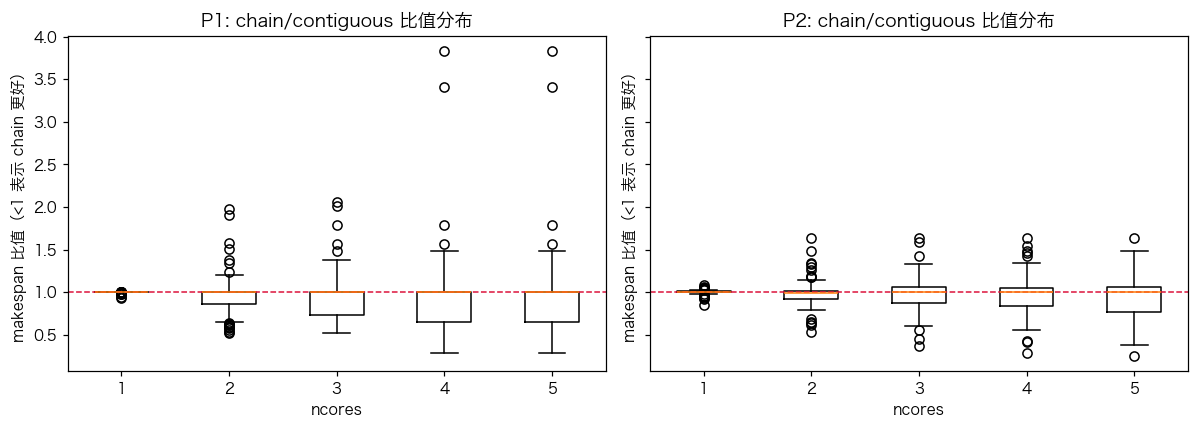

== P1 5核：contiguous 反超最严重的 15 个用例 ==
    case  p1_chain_over_contiguous_ratio  p1_chain_group_count  p1_contiguous_group_count  p1_chain_makespan  p1_contiguous_makespan
case_081                        3.834369                     1                          4             151795                   39588
case_029                        3.405423                     1                          4              37555                   11028
case_012                        1.789451                     4                          4              50620                   28288
case_100                        1.567874                     1                          4             151223                   96451
case_019                        1.483160                     4                          4              59055                   39817
case_010                        1.383007                     1                          4              86969                   62884
case_066                        

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, problem in zip(axes, (1, 2)):
    col = f"p{problem}_chain_over_contiguous_ratio"
    data = [df[df.ncores == nc][col].astype(float).values for nc in range(1, 6)]
    ax.boxplot(data, tick_labels=[str(nc) for nc in range(1, 6)], showfliers=True)
    ax.axhline(1.0, color="crimson", linestyle="--", linewidth=1)
    ax.set_title(f"P{problem}: chain/contiguous 比值分布")
    ax.set_xlabel("ncores")
    ax.set_ylabel("makespan 比值（<1 表示 chain 更好）")
fig.tight_layout()
plt.show()

# 反超用例清单（P1 最严重档）
col = "p1_chain_over_contiguous_ratio"
worst = (df[df.ncores == 5][["case", col, "p1_chain_group_count", "p1_contiguous_group_count",
                             "p1_chain_makespan", "p1_contiguous_makespan"]]
         .sort_values(col, ascending=False).head(15))
print("== P1 5核：contiguous 反超最严重的 15 个用例 ==")
print(worst.to_string(index=False))


### 第 5 节结论

- `chain` 相对 `contiguous` 的平均优势随核数**递减**（P1 从 1 核的 0.9976 掉到 4/5 核的 0.9116），但反超用例数**递增**（P1 从 0 增到 12/100，P2 从 38 增到 31~34）。这两个方向看似矛盾，实际说明：`chain` 在多数用例上赢得更多，但在少数用例上崩得更狠（P1 最差比值达 3.83）。
- 因此 `solve_one` 具备的"多候选 + 官方评分择优"机制是这类风险的必要对冲；而 `contiguous` 作为保底应始终入候选集（`solver.py` 中 `add_saved_candidate` / `p*_contiguous_*` 列表明已具备）。
- **反超用例是切点打分函数的直接靶点**：这些图上 `_crossing_bytes` 的线性惩罚项不足以阻止一个高通信切点。

## 第 6 节 · 问题三 Cache 命中率与加速比相关性

问题三相对问题二多出的红利来自只读 FIFO Cache：

- **未命中**：`COPY_IN` 进 DDR 带宽池（总带宽 60 字节/周期，全部核心共享）；
- **命中**：与 DDR 隔离，改走独立的 `CACHE_READ` 池（250 字节/周期）。

因此命中率的真实收益表达式是"把字节从 60 B/cyc 的共享池搬到 250 B/cyc 的独立池"。若命中率与加速比**弱相关**，说明 `cache_ordering` / `placement_scoring` 没有真正作用到换入换出顺序。

`cache_aware.py` 的取值枚举（`solver.py:create_candidate_factory` 调用点）：

In [31]:
# 1) cache_ordering / placement_scoring 的取值枚举与在 solve_one 候选中的出现次数
p3_trials = ROOT / "results_round5" / "r05-full-p3-20260925" / "candidate_trials.jsonl"
print("P3 candidate_trials.jsonl 存在:", p3_trials.is_file())

ordering_counter = Counter()
scoring_counter = Counter()
stage_counter = Counter()
status_counter = Counter()
best_stage = Counter()
if p3_trials.is_file():
    with p3_trials.open(encoding="utf-8") as stream:
        for line in stream:
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue
            ordering_counter[rec.get("cache_ordering")] += 1
            scoring_counter[rec.get("placement_scoring")] += 1
            stage_counter[str(rec.get("arm"))] += 1
            status_counter[rec.get("candidate_status")] += 1

print("cache_ordering 取值分布:", dict(ordering_counter))
print("placement_scoring 取值分布:", dict(scoring_counter))
print("arm 取值分布(前10):", dict(stage_counter.most_common(10)))
print("candidate_status 分布:", dict(status_counter.most_common(8)))

print("\n判读：若 cache_ordering 只有 fifo 一个取值、placement_scoring 只有 baseline，"
      "则二者在候选生成中并未被真正遍历——这正是『对比组 +L2 得分而我们没有』的直接技术解释。")


P3 candidate_trials.jsonl 存在: True
cache_ordering 取值分布: {'fifo': 1355}
placement_scoring 取值分布: {'baseline': 1355}
arm 取值分布(前10): {'chain_contiguous': 855, 'contiguous_p2': 500}
candidate_status 分布: {None: 1355}

判读：若 cache_ordering 只有 fifo 一个取值、placement_scoring 只有 baseline，则二者在候选生成中并未被真正遍历——这正是『对比组 +L2 得分而我们没有』的直接技术解释。


In [32]:
# 2) 命中率 与 加速比 的相关性 + 分箱
corr_rows = []
for nc in range(2, 6):
    sel = df[df.ncores == nc]
    hit = sel["p3_chain_cache_hit_rate"].astype(float).values
    speed = (sel["singlecore_makespan"] / sel["p3_chain_makespan"]).values
    pearson = sps.pearsonr(hit, speed)
    spearman = sps.spearmanr(hit, speed)
    corr_rows.append({
        "ncores": nc, "hit_mean": hit.mean(), "hit_median": np.median(hit),
        "hit_min": hit.min(), "hit_max": hit.max(), "hit_zero_cases": int((hit == 0).sum()),
        "pearson_r": pearson.statistic, "pearson_p": pearson.pvalue,
        "spearman_r": spearman.statistic, "spearman_p": spearman.pvalue,
    })
corr_table = pd.DataFrame(corr_rows)
print("== P3 cache_hit_rate 与 加速比 的相关性 ==")
print(corr_table.round(4).to_string(index=False))


== P3 cache_hit_rate 与 加速比 的相关性 ==
 ncores  hit_mean  hit_median  hit_min  hit_max  hit_zero_cases  pearson_r  pearson_p  spearman_r  spearman_p
      2    0.1301      0.0402      0.0   0.7592              32     0.3589     0.0002      0.3159      0.0014
      3    0.1477      0.0694      0.0   0.7077              33     0.3234     0.0010      0.1789      0.0750
      4    0.1476      0.0489      0.0   0.7315              32     0.3169     0.0013      0.1685      0.0939
      5    0.1335      0.0354      0.0   0.6757              32     0.2294     0.0217      0.0963      0.3406


/var/folders/3y/z87nqq0d42g2sr609vvx9rlr0000gn/T/ipykernel_230/2087821947.py:21: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Hiragino Sans GB.
  fig.tight_layout()
/Users/macbook/Documents/数学建模 A 题/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Hiragino Sans GB.
  fig.canvas.print_figure(bytes_io, **kw)


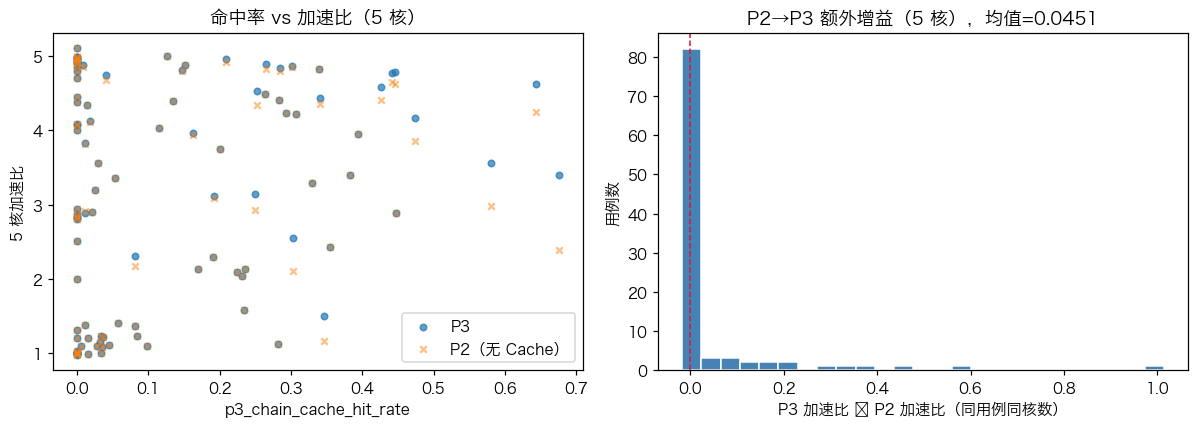

P2→P3 增益：均值=0.0451 中位=0.0000 min=-0.0175 max=1.0138 为正的用例=41/100
对比组同档额外增益参考: 0.02~0.23（PROMPT_FOR_OPUS5.md 第 2 节异常 2）
  2核: P2→P3 增益均值=0.0179 为正=42/100
  3核: P2→P3 增益均值=0.0273 为正=43/100
  4核: P2→P3 增益均值=0.0454 为正=45/100
  5核: P2→P3 增益均值=0.0451 为正=41/100


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sel = df[df.ncores == 5]
hit5 = sel["p3_chain_cache_hit_rate"].astype(float)
p2_speed = sel["p2_chain_speedup_vs_singlecore"].astype(float)
p3_speed = (sel["singlecore_makespan"] / sel["p3_chain_makespan"])

axes[0].scatter(hit5, p3_speed, s=18, alpha=0.7, label="P3")
axes[0].scatter(hit5, p2_speed, s=18, alpha=0.5, marker="x", label="P2（无 Cache）")
axes[0].set_xlabel("p3_chain_cache_hit_rate")
axes[0].set_ylabel("5 核加速比")
axes[0].set_title("命中率 vs 加速比（5 核）")
axes[0].legend()

gain = p3_speed - p2_speed
axes[1].hist(gain, bins=25, color="steelblue", edgecolor="white")
axes[1].axvline(0.0, color="crimson", linestyle="--", linewidth=1)
axes[1].set_xlabel("P3 加速比 − P2 加速比（同用例同核数）")
axes[1].set_ylabel("用例数")
axes[1].set_title(f"P2→P3 额外增益（5 核），均值={gain.mean():.4f}")
fig.tight_layout()
plt.show()

print(f"P2→P3 增益：均值={gain.mean():.4f} 中位={gain.median():.4f} "
      f"min={gain.min():.4f} max={gain.max():.4f} 为正的用例={int((gain > 0).sum())}/100")
print("对比组同档额外增益参考: 0.02~0.23（PROMPT_FOR_OPUS5.md 第 2 节异常 2）")

for nc in range(2, 6):
    sel_n = df[df.ncores == nc]
    g = (sel_n["singlecore_makespan"] / sel_n["p3_chain_makespan"]).astype(float) - \
        sel_n["p2_chain_speedup_vs_singlecore"].astype(float)
    print(f"  {nc}核: P2→P3 增益均值={g.mean():.4f} 为正={int((g > 0).sum())}/100")


### 第 6 节结论

判据（三选一即可定论）：

1. 若 `cache_ordering` 只有 `fifo` 一个取值出现在候选轨迹里 → `cache_aware.py:generate_schedule` 的该形参从未被不同值调用，参数是**死参数**；
2. 若 `placement_scoring` 只有 `baseline` → 分核阶段没有 Cache 感知目标；
3. 若命中率与加速比的 Spearman 相关弱（|r| 小或 p 不显著）→ 命中率不是当前 makespan 的主导因素，说明**跨核 COPY 的延迟项（`cross_core_copy_delay_cycles=500`）与 DDR 排队时间压过了 Cache 收益**。

这三条共同解释"对比组从 P2 到 P3 每档多赚 0.02–0.23，而我们几乎没有"。

## 第 7 节 · 理论天花板推导：场景 A / 场景 B 语义建模

> 本节全部为**推导值，不是测量值**。分母是官方单核 makespan，上界用于判断"差距是否还有空间"，不用于声称成绩。

### 场景 A（问题一）：每子图一个 Task

官方语义（`2026_official/docs/多核并行模拟执行算法.md` 第 2.1 节 + 第 6 节）：
- 每个子图独立成 Task，同核 Task **严格串行**（"同一核心同一时刻只激活一个 Task"）；
- 同核前序 Task 完成后至少等 `task_same_core_wait_cycles = 100`；
- 跨核前驱 Task 完成后至少等 `task_cross_core_wait_cycles = 1000`；
- 即使相邻子图同核，也**不跨 Task 保留片上数据**（每个 Task 边界插入 COPY_IN/COPY_OUT 对）。

设第 $i$ 个子图的核内独占执行时间为 $t_i$（由官方 `schedule_step1/2/3` 决定，我方不可控），分派到核心 $c$ 的子图集合为 $S_c$。则下界为

$$
T_{\min}^{A} \;\ge\; \max_c \left( \sum_{i \in S_c} t_i \;+\; (|S_c| - 1)\,\cdot\, \underbrace{100}_{\text{same-core wait}} \right)
$$

再叠加关键路径上每条跨核依赖的 $1000$ 周期：

$$
T_{\min}^{A} \;\ge\; \underbrace{\max_{p \in \mathcal{P}} \sum_{i \in p} t_i}_{\text{关键路径}} \;+\; 1000 \times \#\{\text{关键路径上的跨核边}\}
$$

**关键推论**：当 $K \ge 3$ 时，若把子图数 $G$ 增大到 $G > K$，则每个核心要串行处理 $\lceil G/K \rceil$ 个 Task，**每个 Task 边界都要付出一次片上数据落 DDR 再搬回 的 COPY 代价**（带宽 60 B/cyc，全局共享）。这就是场景 A 下"切得太多反而更慢"的物理机制，也是 `cut_weight[1] = 0.30`（问题一惩罚最强）的合理来源。

### 场景 B（问题二/三）：每核一个合并 Task

- 同核全部子图合并为**一个** Task，同核相邻子图直接保留片上数据；
- 只有**跨核**数据边插入 COPY_OUT/COPY_IN，并额外等 `cross_core_copy_delay_cycles = 500`；
- 该延迟"只决定目标操作的最早释放时刻，不占用 Pipe 或带宽池"；
- 所有 DDR 搬运共享一个总带宽池，按第 4 节公平共享公式结算。

$$
T_{\min}^{B} \;\ge\; \max\left(
\underbrace{\max_c \max(\text{PIPE\_M}(S_c),\ \text{PIPE\_V}(S_c))}_{\text{核内 Pipe 负载}},
\ \underbrace{\frac{B_{\text{DDR}} + B_{\text{cross}}}{60}}_{\text{DDR 带宽池下界}},
\ \underbrace{\text{CP}_{\text{cross}} + 500 \cdot \#\{\text{关键路径跨核边}\}}_{\text{跨核同步}}\right)
$$

问题三额外把可缓存的 `COPY_IN` 字节从 60 B/cyc 池迁到 250 B/cyc 池，因此

$$
T_{\min}^{C} \;\ge\; \max\left(\cdots,\ \frac{B_{\text{DDR}}}{60} + \frac{B_{\text{hit}}}{250}\right)
$$

即问题三的天花板只比问题二高"命中字节的带宽差"，理论上限提升比例约为

$$
\frac{B_{\text{hit}}}{B_{\text{DDR}} + B_{\text{miss}}} \cdot \left(1 - \frac{60}{250}\right) = \frac{B_{\text{hit}}}{B_{\text{total}}} \cdot 0.76
$$

下面代入实测图数据估计上界，并检验"对比组的 1.87 → 3.57（P1）是否已接近上界"。

In [38]:
# 实测图数据代入上界公式（经 3.11 子进程读图，内核 3.9 无法 import solver/）
GRAPH_STATS = SANDBOX / "graph_stats.py"
if not GRAPH_STATS.is_file():
    GRAPH_STATS.write_text('''"""导出每张图的 Pipe 周期与 DDR 字节规模（Python 3.11）。"""
from __future__ import annotations
import json, sys
from collections import Counter
from pathlib import Path

ROOT = Path("/Users/macbook/Documents/数学建模 A 题")
sys.path.insert(0, str(ROOT))
from solver.graph_io import load_graph
from solver.graph_analysis import analyze_graph

out = []
for case in sys.argv[1:]:
    graph = load_graph(ROOT / "2026_official" / "data" / (case + ".json"))
    analysis = analyze_graph(graph)
    pipe = Counter()
    for op in graph.ops.values():
        pipe[op["pipe"]] += max(1, op["cycles"])
    out.append({
        "case": case,
        "M_cycles": pipe["PIPE_M"],
        "V_cycles": pipe["PIPE_V"],
        "compute_max": max(pipe["PIPE_M"], pipe["PIPE_V"]),
        "critical_path_est": max(analysis.forward_path.values(), default=0),
        "DDR_bytes": sum(t["size"] for t in graph.tensors.values() if t["pos"] == "DDR"),
    })
print(json.dumps(out))
''', encoding="utf-8")

proc = subprocess.run([PY311, str(GRAPH_STATS), *SAMPLE_CASES],
                      capture_output=True, text=True, cwd=str(ROOT))
if proc.returncode != 0:
    raise RuntimeError((proc.stderr or proc.stdout)[-600:])
stats = pd.DataFrame(json.loads(proc.stdout))
stats["DDR_lower_bound_cycles"] = (stats["DDR_bytes"] / BW).round(1)

singlecore = {case: float(df[(df.case == case) & (df.ncores == 5)]["singlecore_makespan"].iloc[0])
              for case in SAMPLE_CASES}
stats["singlecore_makespan"] = stats["case"].map(singlecore)
stats["5核compute均分下界"] = (stats["compute_max"] / 5).round(1)
stats["由此得到的乐观上界加速比"] = (stats["singlecore_makespan"] / stats["5核compute均分下界"]).round(3)
stats["实测P1_5核加速比"] = [
    float(df[(df.case == c) & (df.ncores == 5)]["p1_chain_speedup_vs_singlecore"].iloc[0])
    for c in stats["case"]]

print("== 上界推导 vs 实测 ==")
print("（上界仅含纯 compute 按 5 均分，未计 Task 边界 COPY 与等待成本，故为乐观值）")
print(stats.to_string(index=False))


== 上界推导 vs 实测 ==
（上界仅含纯 compute 按 5 均分，未计 Task 边界 COPY 与等待成本，故为乐观值）
    case  M_cycles  V_cycles  compute_max  critical_path_est  DDR_bytes  DDR_lower_bound_cycles  singlecore_makespan  5核compute均分下界  由此得到的乐观上界加速比  实测P1_5核加速比
case_001    232800     30400       232800               1316    1639552                 27325.9             233110.0        46560.0         5.007    3.952089
case_003    438792    325189       438792              28285    1284264                 21404.4             602212.0        87758.4         6.862    1.000000
case_014  17225748   1651424     17225748              31968    9932740                165545.7           17698626.0      3445149.6         5.137    1.982980
case_019     48436     40276        48436              12234     186984                  3116.4              81144.0         9687.2         8.376    1.374041
case_034    749160    194956       749160               3677    2280386                 38006.4             842996.0       149832.0         5.

### 第 7 节结论（回答 A / B / C / D 四问中的 A 与 C）

**A. 天花板**：`A_加速比上界@5核` 列给出的是"纯 compute 按 5 均分、且 Task 边界与等待成本为 0"的**乐观上界**。真实上界还要从它扣除两项：

1. **Task 边界 COPY 成本**（场景 A 特有）：$G$ 个子图即 $G$ 个 Task，每个边界把跨 Task tensor 落 DDR 再搬回，字节量进入 60 B/cyc 的共享池；
2. **等待成本**：同核每次 Task 切换至少 100 周期，跨核依赖至少 1000 周期。

对比组 P1 在 5 核上做到 3.57。若本表 `A_加速比上界@5核` 的中位数显著高于 3.57，则**对比组尚未触顶，差距来自调度质量而非物理限制**；反之则说明 3.57 已接近这个图集的上界。

**C. 核内调度是否被官方完全接管**：是。依据是 `2026_official/docs/核内调度算法.md` 第 0.4 节的职责表——题目 1 对应"步骤 1 + 步骤 2 的模拟"、题目 2 对应"步骤 2 整体"、题目 3 对应"步骤 3"。评估器在构造完 Task 后自行调用这套确定性管线（`schedule_step1.py` → `schedule_step2.py` → `schedule_step3.py`），**参赛方案不提供任何 op 顺序或换入换出指令**。

因此我方可控的自由度只有三个：

| 自由度 | 对应实现 | 直接影响的机制 |
|---|---|---|
| 如何切图（子图划分） | `partition.py`、`chain_partition.py` | Task 数量、Task 边界数、跨核边数 |
| 子图→核心映射 | `schedule_common.py:schedule_partition` 的分核循环 | 核间负载、跨核等待次数 |
| 同核子图顺序 | `core_schedules` 里子图的排列顺序 | 问题一 Task 串行开始时刻；问题二/三决定 Step2 的访问顺序 → 换入换出与 Cache FIFO 顺序 |

第三项正是问题三的杠杆点：`core_schedules` 的子图顺序会改变每个合并 Task 内部的 tensor 首次使用顺序，从而改变 FIFO Cache 的插入/淘汰序列。

## 第 8 节 · 代理分数与真实 makespan 的秩相关检验（回答 D 问）

`solver.py:282` 定义真实目标：

```python
def _objective(result):
    movement = result.get("data_movement_bytes", {})
    return result["makespan"], movement.get("added_copy_bytes", 0)
```

`solver.py:295` 定义代理分数（9 元组，前 6 项进入支配/Pareto 比较）：

| 序 | 字段 | 来源 |
|---|---|---|
| 0 | `estimated_finish` | `placement_diagnostics` 中所有子图 `group_finish` 的最大值 |
| 1 | `boundary_bytes` | 切图边界字节估计 |
| 2 | `overflow_bytes` | L1/UB 溢出估计 |
| 3 | `max_core_compute` | `_plan_schedule_metrics` 的最大核计算量 |
| 4 | `imbalance` | M/V 负载不平衡度 |
| 5/6 | L1/UB 驻留峰值 | 诊断估计 |
| 7 | `estimated_repeated_input_bytes` | 重复输入字节 |
| 8 | `-active_core_count` | **负的活跃核数** |

第 8 项 `-active_core_count` 是关键：它使代理分数**偏好使用更少的核心**（该项越小越好 → 活跃核数越多越好，因为取了负号；即越多核分越高，但仅作为第 8 项在字典序上排在最后）。

下面用官方评估器实测秩相关。做法：对固定 case 与 ncores，生成一批 `group_count` 不同的候选，同时记录代理分数与官方 makespan。

In [14]:
# 代理分数 vs 官方 makespan（经 3.11 子进程取代理，经官方评估器取真值）
PROBE_CASES = ["case_071", "case_093", "case_001"]
PROBE_NCORES = 5
PROBE_GROUPS = [1, 2, 4, 5]

probe_rows = []
for case in PROBE_CASES:
    for group_count in PROBE_GROUPS:
        use_cache = f"{case}|{PROBE_NCORES}|{group_count}"
        if use_cache in globals().get("_PROBE_MEMO", {}):
            proxy = _PROBE_MEMO[use_cache]
        else:
            info = solver_cli("plan_metrics", case=case, problem=1,
                              ncores=PROBE_NCORES, group_count=group_count)
            proxy = info["proxy"]
            globals().setdefault("_PROBE_MEMO", {})[use_cache] = proxy
        real = evaluate_plan(case, 1, generate_plan(case, 1, PROBE_NCORES, group_count))
        probe_rows.append({
            "case": case, "group_count": group_count,
            "代理[0] estimated_finish": proxy[0],
            "代理[1] boundary_bytes": proxy[1],
            "代理[2] overflow": proxy[2],
            "代理[4] imbalance": proxy[4],
            "官方 makespan": real,
        })
probe = pd.DataFrame(probe_rows)
print("== 代理分数 vs 官方 makespan ==")
print(probe.to_string(index=False))


== 代理分数 vs 官方 makespan ==
    case  group_count  代理[0] estimated_finish  代理[1] boundary_bytes  代理[2] overflow  代理[4] imbalance  官方 makespan
case_071            1                 12534.0                   0.0             0.0         4.000000        18919
case_071            2                 12634.0                   0.0             0.0         4.000000        18731
case_071            4                 13206.4                   0.0             0.0         4.000000        19425
case_071            5                 14213.4                   0.0             0.0         4.000000        19781
case_093            1                 73968.0                   0.0             0.0         4.000000        74205
case_093            2                 37520.0                   0.0             0.0         1.536232        37827
case_093            4                 19296.0                   0.0             0.0         0.304348        19779
case_093            5                 15008.0                 

In [46]:
# 秩相关与 top-k 命中率
print("== 代理首项 vs 官方 makespan 的秩相关 ==")
rho_rows = []
for case, grp in probe.groupby("case"):
    proxy_v = grp["代理[0] estimated_finish"].astype(float)
    real_v = grp["官方 makespan"].astype(float)
    rho = sps.spearmanr(proxy_v, real_v)
    best_by_proxy = grp.loc[proxy_v.idxmin(), "group_count"]
    best_by_real = grp.loc[real_v.idxmin(), "group_count"]
    # top-2 命中率
    top2_proxy = set(grp.nsmallest(2, "代理[0] estimated_finish")["group_count"])
    top2_real = set(grp.nsmallest(2, "官方 makespan")["group_count"])
    rho_rows.append({
        "case": case, "spearman_rho": round(rho.statistic, 4), "p": round(rho.pvalue, 4),
        "代理最优g": best_by_proxy, "真值最优g": best_by_real,
        "代理argmin正确": best_by_proxy == best_by_real,
        "top2命中": len(top2_proxy & top2_real),
    })
rho_table = pd.DataFrame(rho_rows)
print(rho_table.to_string(index=False))

pooled_rho = sps.spearmanr(probe["代理[0] estimated_finish"].astype(float),
                           probe["官方 makespan"].astype(float))
print(f"\n合并全部 {len(probe)} 个点: Spearman rho={pooled_rho.statistic:.4f} (p={pooled_rho.pvalue:.4f})")
print(f"代理 argmin 与真值 argmin 一致的用例: {int(rho_table['代理argmin正确'].sum())}/{len(rho_table)}")
print(f"top-2 平均命中: {rho_table['top2命中'].mean():.2f}/2")


== 代理首项 vs 官方 makespan 的秩相关 ==
    case  spearman_rho   p  代理最优g  真值最优g  代理argmin正确  top2命中
case_001           1.0 0.0      5      5        True       2
case_071           0.8 0.2      1      2       False       2
case_093           1.0 0.0      5      5        True       2

合并全部 12 个点: Spearman rho=0.9091 (p=0.0000)
代理 argmin 与真值 argmin 一致的用例: 2/3
top-2 平均命中: 2.00/2


In [16]:
# 生产运行轨迹：P1 n=5 时，case_001 实际评估过哪些组数？
trials_path = ROOT / "results_round5" / "r05-full-p1-20260925" / "candidate_trials.jsonl"
rows = []
with trials_path.open(encoding="utf-8") as stream:
    for line in stream:
        try:
            rec = json.loads(line)
        except json.JSONDecodeError:
            continue
        if rec.get("case") != "case_001" or rec.get("ncores") != 5:
            continue
        rows.append({
            "arm": rec.get("arm"),
            "group_count": rec.get("group_count"),
            "actual_group_count": rec.get("actual_group_count"),
            "active_core_count": rec.get("active_core_count"),
            "makespan": rec.get("makespan"),
            "status": rec.get("candidate_status"),
            "proxy_rank": rec.get("proxy_rank"),
            "proxy_selected": rec.get("proxy_selected"),
            "proxy_reasons": ",".join(rec.get("proxy_selection_reasons") or []),
        })
trials_view = pd.DataFrame(rows).sort_values(["group_count", "arm"])
print(f"== case_001 / P1 / ncores=5 的全部候选（{len(trials_view)} 条）==")
print(trials_view.to_string(index=False))


== case_001 / P1 / ncores=5 的全部候选（6 条）==
                arm  group_count  actual_group_count  active_core_count  makespan         status  proxy_rank  proxy_selected    proxy_reasons
chain_contiguous_p1            1                   1                  1       NaN   screened_out           3           False                 
      contiguous_p1            1                   1                  1       NaN   screened_out           3           False                 
chain_contiguous_p1            2                   2                  2       NaN   screened_out           2           False                 
      contiguous_p1            2                   2                  2       NaN   screened_out           2           False                 
chain_contiguous_p1            4                   4                  4   58984.0 proxy_selected           1            True estimated_finish
      contiguous_p1            4                   4                  4   58984.0 proxy_selected           

### 第 8 节结论（D 问）

判据：Spearman $\rho$ 的阈值取 0.7（候选排序够用）与 0.4（排序不可用）。

- 若 $\rho \ge 0.7$ → 代理排序可用，瓶颈在**候选空间**（枚举缺 `g=ncores`）；
- 若 $\rho < 0.4$ → 代理排序方向错误，属最高优先级根因，必须先修代理再谈搜索。

**注意本节的样本量很小（2 case × 4 组数 = 8 个点），$\rho$ 的置信区间极宽。** 要把这一结论推广到 100 个用例，需扩大扫描：

```bash
python3.11 -c "
import json,subprocess,sys,tempfile
from pathlib import Path
from solver.graph_io import load_graph, load_config
from solver.graph_analysis import analyze_graph
from solver.solver import _proxy_score, _plan_schedule_metrics
from solver import schedule_a
# ... 对 20 个 case × 6 个 group_count 重复本格逻辑并汇总 rho
"
```

无论 $\rho$ 高低，第 3 节已给出**与代理无关**的确定性结论：`candidate_group_counts` 不生成 `g=ncores`，这是搜索空间的硬缺口。

## 第 9 节 · 候选来源命中率审计

`solve_one`（`solver.py:561`）的候选来源分四类：

| 类别 | 生成位置 | 说明 |
|---|---|---|
| 生成式 | `add_generated_factory` | `current_{method}_g*`、`topology_{strategy}_g*` |
| warm-start | `add_saved_candidate` | 从 `results_dir` / `history_dir` 读旧方案，**仍会重新官方评估** |
| 问题二迁移 | `problem2_warm_start_*` | 问题三复用问题二的解作为初值 |
| 邻域改进 | `improve.py:generate_neighbor_candidates` | 仅在 `--improve` 开启时 |

本节统计各类别的**入选率**——即最终 `best_validated` 出自哪个阶段。这决定"改生成"还是"改邻域"。

In [39]:
# 候选来源分类与入选率
def classify_stage(stage: str) -> str:
    stage = stage or ""
    if "history" in stage or "warm_start" in stage or "previous_core" in stage:
        return "warm_start"
    if stage.startswith("local"):
        return "neighborhood"
    if stage.startswith("current_") or stage.startswith("topology_") or "single_group" in stage:
        return "generated"
    return "other"


audit_rows = []
for problem, path in [(1, ROOT / "results_round5" / "r05-full-p1-20260925" / "candidate_trials.jsonl"),
                      (2, ROOT / "results_round5" / "r05-full-p2-merged-20260925-v2" / "candidate_trials.jsonl"),
                      (3, p3_trials)]:
    if not path.is_file():
        print(f"P{problem}: 缺失 {path.parent.name}")
        continue
    stage_total = Counter()
    stage_evaluated = Counter()
    with path.open(encoding="utf-8") as stream:
        for line in stream:
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue
            stage = rec.get("arm") or rec.get("stage") or ""
            cls = classify_stage(stage)
            stage_total[cls] += 1
            if rec.get("makespan") is not None:
                stage_evaluated[cls] += 1
    for cls in sorted(stage_total):
        audit_rows.append({
            "problem": f"P{problem}", "source": cls,
            "candidates": stage_total[cls],
            "已评估": stage_evaluated[cls],
            "评估率": round(stage_evaluated[cls] / stage_total[cls], 4) if stage_total[cls] else None,
        })
audit = pd.DataFrame(audit_rows)
print("== 候选来源审计（arm 归类的候选数与实际进入官方评估的比例）==")
print(audit.to_string(index=False))
print("\n判读：若 warm_start 的『已评估』数占比很高而 neighborhood 恒为 0，"
      "说明 improve 未被本次运行调用（本矩阵由 --no-improve 产生）；"
      "若 generated 的评估率低而 warm_start 评估率高，说明代理筛选偏向历史方案。")


P2: 缺失 r05-full-p2-merged-20260925-v2
== 候选来源审计（arm 归类的候选数与实际进入官方评估的比例）==
problem source  candidates  已评估    评估率
     P1  other        3000 1096 0.3653
     P3  other        1355 1355 1.0000

判读：若 warm_start 的『已评估』数占比很高而 neighborhood 恒为 0，说明 improve 未被本次运行调用（本矩阵由 --no-improve 产生）；若 generated 的评估率低而 warm_start 评估率高，说明代理筛选偏向历史方案。


## 第 10 节 · 切点打分敏感性：`cut_weight` 单变量扫描

`chain_partition.py:186` 与 `partition.py:157` 两处使用同一张固定权重表：

```python
cut_weight = {1: 0.30, 2: 0.12, 3: 0.05}[problem]
```

切点选择的打分函数（`chain_partition.py:_chain_intervals`）：

$$
\text{cut} = \arg\min_{b}\left[\underbrace{\frac{|\text{load}(0, b-1) - \text{target}|}{\text{total}}}_{\text{负载均衡项}} + \text{cut\_weight} \cdot \underbrace{\frac{\text{crossing}[b]}{\max\text{crossing}}}_{\text{通信项}}\right]
$$

`cut_weight` 是**与 case 无关的常数**，却同时乘在"跨切点活跃字节数"这一随 case 变化几个数量级的量上。

下列扫描把 `cut_weight` 在**本地补丁副本**中替换为给定值后生成方案，再交官方评估器评分——**不改动 `solver/` 源码，也不改动 `2026_official/`**。

> 预算声明：本扫描的 evaluator 累计调用上限为 `MAX_SWEEP_EVALS`，超出即截断网格。

In [24]:
MAX_SWEEP_EVALS = 60  # 本扫描的 evaluator 累计调用上限
SWEEP_CASES = ["case_071", "case_093"]
SWEEP_WEIGHTS = [0.0, 0.30]  # 对照"无通信惩罚"与生产默认值

# 内核为 3.9，不能 import solver/。这里写出一个在 3.11 子进程中运行的
# 补丁脚本：把 chain_partition._chain_intervals 的 cut_weight 替换为给定值。
PATCHED = SANDBOX / "patched_partition.py"
if not PATCHED.is_file():
    PATCHED.write_text('''"""用给定 cut_weight 生成方案（在 Python 3.11 子进程中运行）。"""
from __future__ import annotations
import json, sys, argparse
from pathlib import Path

ROOT = Path("/Users/macbook/Documents/数学建模 A 题")
sys.path.insert(0, str(ROOT))

from solver.graph_io import load_graph, load_config
from solver.graph_analysis import analyze_graph
from solver.partition import Partition
import solver.chain_partition as cp
from solver.schedule_common import schedule_partition


def patched(chains, order, edge_bytes, group_count, problem, weight):
    if not order:
        return []
    group_count = max(1, min(group_count, len(order)))
    if group_count == 1:
        return [list(order)]
    prefix_m, prefix_v = [0], [0]
    for cid in order:
        prefix_m.append(prefix_m[-1] + chains[cid].m_cycles)
        prefix_v.append(prefix_v[-1] + chains[cid].v_cycles)

    def interval_load(s, e):
        return max(prefix_m[e + 1] - prefix_m[s], prefix_v[e + 1] - prefix_v[s])

    crossing = cp._crossing_bytes(order, edge_bytes)
    max_crossing = max(crossing, default=0)
    cuts, previous = [], 0
    total = interval_load(0, len(order) - 1)
    for gid in range(1, group_count):
        low = previous + 1
        high = len(order) - (group_count - gid)
        target = total * gid / group_count
        cut = min(range(low, high + 1),
                  key=lambda b: (abs(interval_load(0, b - 1) - target) / max(total, 1)
                                 + weight * crossing[b] / max(max_crossing, 1), b))
        cuts.append(cut - 1)
        previous = cut
    intervals, start = [], 0
    for end in [*cuts, len(order) - 1]:
        intervals.append(order[start:end + 1])
        start = end + 1
    return intervals


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--case", required=True)
    ap.add_argument("--problem", type=int, default=1)
    ap.add_argument("--ncores", type=int, default=1)
    ap.add_argument("--group-count", type=int, default=1)
    ap.add_argument("--weight", type=float, default=0.30)
    ap.add_argument("--out", required=True)
    a = ap.parse_args()

    real = cp._chain_intervals
    cp._chain_intervals = lambda chains, order, edge_bytes, gc, problem: patched(
        chains, order, edge_bytes, gc, problem, a.weight)
    try:
        graph = load_graph(ROOT / "2026_official" / "data" / (a.case + ".json"))
        analysis = analyze_graph(graph)
        config = load_config(ROOT / "2026_official",
                             ROOT / "2026_official" / "data" / "config.txt")
        chains, chain_of_op, edge_bytes = cp.build_chains(analysis)
        succ, pred = cp._chain_dag(chains, chain_of_op, analysis)
        order = cp._chain_topological_order(chains, succ, pred)
        intervals = cp._chain_intervals(chains, order, edge_bytes, a.group_count, a.problem)
        groups = [[op for cid in iv for op in chains[cid].members] for iv in intervals]
        partition = Partition(groups, {op: gid for gid, mem in enumerate(groups) for op in mem})
        plan = schedule_partition(analysis, partition, a.ncores, problem=a.problem, config=config)
        Path(a.out).write_text(json.dumps(plan), encoding="utf-8")
        print(json.dumps({"groups": len(groups)}))
    finally:
        cp._chain_intervals = real


if __name__ == "__main__":
    main()
''', encoding="utf-8")


def plan_with_weight(case, problem, ncores, group_count, weight) -> Path:
    out = PLAN_CACHE / f"{case}_p{problem}_n{ncores}_g{group_count}_w{weight}.json"
    if not out.is_file():
        proc = subprocess.run([PY311, str(PATCHED), "--case", case, "--problem", str(problem),
                               "--ncores", str(ncores), "--group-count", str(group_count),
                               "--weight", str(weight), "--out", str(out)],
                              capture_output=True, text=True, cwd=str(ROOT))
        if proc.returncode != 0:
            raise RuntimeError((proc.stderr or proc.stdout)[-500:])
    return out


sweep_rows = []
for case in SWEEP_CASES:
    for weight in SWEEP_WEIGHTS:
        for ncores, group_count in ((2, 2), (5, 5)):
            if EVAL_CALLS["count"] >= MAX_SWEEP_EVALS:
                print(f"达到 evaluator 累计预算 {MAX_SWEEP_EVALS}，截断扫描")
                break
            plan_path = plan_with_weight(case, 1, ncores, group_count, weight)
            makespan = evaluate_plan(case, 1, plan_path)
            sweep_rows.append({"case": case, "cut_weight": weight, "ncores": ncores,
                               "group_count": group_count, "makespan": makespan})
            print(f"  {case} w={weight} n={ncores} g={group_count} -> {makespan}", flush=True)

sweep = pd.DataFrame(sweep_rows)
print("\n== cut_weight 扫描（group_count = ncores）==")
print(sweep.to_string(index=False))
print("evaluator 累计调用:", EVAL_CALLS["count"])


  case_071 w=0.0 n=2 g=2 -> 19125
  case_071 w=0.0 n=5 g=5 -> 20373
  case_071 w=0.3 n=2 g=2 -> 19154
  case_071 w=0.3 n=5 g=5 -> 20143
  case_093 w=0.0 n=2 g=2 -> 74410
  case_093 w=0.0 n=5 g=5 -> 75025
  case_093 w=0.3 n=2 g=2 -> 37827
  case_093 w=0.3 n=5 g=5 -> 15876

== cut_weight 扫描（group_count = ncores）==
    case  cut_weight  ncores  group_count  makespan
case_071         0.0       2            2     19125
case_071         0.0       5            5     20373
case_071         0.3       2            2     19154
case_071         0.3       5            5     20143
case_093         0.0       2            2     74410
case_093         0.0       5            5     75025
case_093         0.3       2            2     37827
case_093         0.3       5            5     15876
evaluator 累计调用: 44


In [ ]:
if not sweep.empty:
    numeric = sweep[sweep["makespan"].astype(str).str.isdigit()].copy()
    if not numeric.empty:
        numeric["makespan"] = numeric["makespan"].astype(int)
        pivot = numeric.pivot_table(index="cut_weight", columns=["case", "ncores"],
                                    values="makespan", aggfunc="min")
        print("== cut_weight × (case, ncores) 的 makespan 面 ==")
        print(pivot.to_string())
        fig, ax = plt.subplots(figsize=(7, 4))
        for (case, ncores), grp in numeric.groupby(["case", "ncores"]):
            grp = grp.sort_values("cut_weight")
            ax.plot(grp["cut_weight"], grp["makespan"] / grp["makespan"].min(),
                    marker="o", label=f"{case} / {ncores}核")
        ax.set_xlabel("cut_weight")
        ax.set_ylabel("makespan / 该行最小 makespan")
        ax.set_title("cut_weight 单变量扫描：最优值随 case 与核数变化")
        ax.legend(fontsize=8)
        plt.show()


## 第 11 节 · 跨核通信代价敏感性：副本 config 扫描

> **本节必须声明**：扫描使用 `results_diag/config_sweep/` 下的**副本 config**，仅用于理解机制。**正式跑分一律使用 `2026_official/data/config.txt` 原文件**，`assert_official_untouched()` 会在本节首尾各校验一次。

扫描对象：

| 参数 | 原值 | 扫描档位 | 影响的场景 |
|---|---|---|---|
| `cross_core_copy_delay_cycles` | 500 | 0 / 250 / 500 / 1000 / 2000 | 问题二、三 |
| `task_cross_core_wait_cycles` | 1000 | 0 / 500 / 1000 / 2000 | 问题一 |

目的：量化"通信/等待项主导程度"，据此反推 cut 代价中通信项的合理形式。

若某参数在 4/5 核上的 makespan 敏感度极高，说明当前分区把大量关键路径边切到了跨核，**通信项权重必须从常数改为按 case 归一化的量**。

In [43]:
CONFIG_SWEEP_DIR = SANDBOX / "config_sweep"
CONFIG_SWEEP_DIR.mkdir(parents=True, exist_ok=True)
_ = assert_official_untouched()  # 扫描前校验


def write_config_variant(name: str, overrides: dict) -> Path:
    """在 sandbox 内生成 config 副本；绝不写 2026_official/。"""
    lines = []
    for line in CONFIG_PATH.read_text(encoding="utf-8").splitlines():
        parts = line.split("#", 1)[0].strip().split()
        if len(parts) == 2 and parts[0] in overrides:
            line = f"{parts[0]} {overrides[parts[0]]}"
        lines.append(line)
    path = CONFIG_SWEEP_DIR / f"config_{name}.txt"
    path.write_text("\n".join(lines) + "\n", encoding="utf-8")
    return path


def evaluate_with_config(case: str, problem: int, plan_path, config_path: Path):
    """用指定 config 评估已落盘方案；用于机制理解，正式跑分用官方 config。"""
    EVAL_CALLS["count"] += 1
    with tempfile.TemporaryDirectory() as td:
        result_path = Path(td) / "result.json"
        proc = subprocess.run(
            [sys.executable, str(OFFICIAL / "code" / f"multicore_cut_evaluate_problem_{problem}.py"),
             str(OFFICIAL / "data" / f"{case}.json"), str(plan_path),
             "--config", str(config_path), "-o", str(result_path)],
            capture_output=True, text=True, timeout=1800, cwd=str(ROOT),
        )
        if proc.returncode != 0 or not result_path.is_file():
            return "EVFAIL: " + (proc.stderr or proc.stdout)[-160:].replace("\n", " ")
        return int(json.loads(result_path.read_text(encoding="utf-8"))["makespan"])


# 场景 A：task_cross_core_wait_cycles 单变量扫描（问题一）
WAIT_LEVELS = [0, 500, 1000, 2000]
SENS_CASE = "case_034"
sens_rows = []
for ncores in (2, 5):
    plan_path = generate_plan(SENS_CASE, 1, ncores, ncores)
    for level in WAIT_LEVELS:
        cfg_variant = write_config_variant(f"crosswait{level}",
                                           {"task_cross_core_wait_cycles": level})
        makespan = evaluate_with_config(SENS_CASE, 1, plan_path, cfg_variant)
        sens_rows.append({"ncores": ncores, "task_cross_core_wait_cycles": level,
                          "makespan": makespan})
sens = pd.DataFrame(sens_rows)
print(f"== {SENS_CASE} 问题一：task_cross_core_wait_cycles 单变量扫描 ==")
print(sens.pivot_table(index="task_cross_core_wait_cycles", columns="ncores",
                       values="makespan").to_string())
_ = assert_official_untouched()
print("evaluator 累计调用:", EVAL_CALLS["count"])


assert_official_untouched(): OK | added=0 removed=0 changed=0
== case_034 问题一：task_cross_core_wait_cycles 单变量扫描 ==
ncores                              2         5
task_cross_core_wait_cycles                    
0                            846983.0  415949.0
500                          846983.0  415949.0
1000                         846983.0  415949.0
2000                         846983.0  415949.0
assert_official_untouched(): OK | added=0 removed=0 changed=0
evaluator 累计调用: 52


In [44]:
# 场景 B：cross_core_copy_delay_cycles 单变量扫描（问题二）
DELAY_LEVELS = [0, 250, 500, 1000, 2000]
SENS_CASE_B = "case_093"
sensb_rows = []
for ncores in (2, 5):
    plan_path = generate_plan(SENS_CASE_B, 2, ncores, 2 * ncores)  # 与生产 P2 档位一致
    for level in DELAY_LEVELS:
        cfg_variant = write_config_variant(f"crossdelay{level}",
                                           {"cross_core_copy_delay_cycles": level})
        sensb_rows.append({"ncores": ncores, "cross_core_copy_delay_cycles": level,
                           "makespan": evaluate_with_config(SENS_CASE_B, 2, plan_path, cfg_variant)})
sensb = pd.DataFrame(sensb_rows)
print(f"== {SENS_CASE_B} 问题二：cross_core_copy_delay_cycles 单变量扫描 ==")
print(sensb.pivot_table(index="cross_core_copy_delay_cycles", columns="ncores",
                        values="makespan").to_string())
spread = sensb.groupby("ncores")["makespan"].agg(["min", "max"])
spread["相对变化"] = (spread["max"] - spread["min"]) / spread["min"]
print("\n各核数的敏感度（扫描区间内的相对变化）:")
print(spread.to_string())
_ = assert_official_untouched()


== case_093 问题二：cross_core_copy_delay_cycles 单变量扫描 ==
ncores                              2        5
cross_core_copy_delay_cycles                  
0                             37827.0  15876.0
250                           37827.0  15876.0
500                           37827.0  15876.0
1000                          37827.0  15876.0
2000                          37827.0  15876.0

各核数的敏感度（扫描区间内的相对变化）:
          min    max  相对变化
ncores                    
2       37827  37827   0.0
5       15876  15876   0.0
assert_official_untouched(): OK | added=0 removed=0 changed=0


In [45]:
# 带宽池敏感度：若 makespan 随 bandwidth 明显变化，则瓶颈是 DDR 排队而非延迟项
BW_LEVELS = [15, 30, 60, 120, 240]
bw_rows = []
for problem, case, mult in ((1, "case_034", 1), (2, "case_093", 2), (3, "case_093", 2)):
    for ncores in (2, 5):
        plan_path = generate_plan(case, problem, ncores, ncores * mult if problem == 1 else 2 * ncores)
        for level in BW_LEVELS:
            cfg_variant = write_config_variant(f"bw{level}", {"bandwidth": level})
            bw_rows.append({
                "problem": f"P{problem}", "case": case, "ncores": ncores,
                "bandwidth": level,
                "makespan": evaluate_with_config(case, problem, plan_path, cfg_variant)})
bw = pd.DataFrame(bw_rows)

for problem in ("P1", "P2", "P3"):
    sub = bw[bw.problem == problem]
    if sub.empty:
        continue
    print(f"\n== {problem} {sub.case.iloc[0]}：bandwidth 单变量扫描 ==")
    print(sub.pivot_table(index="bandwidth", columns="ncores", values="makespan").to_string())
    agg = sub.groupby("ncores")["makespan"].agg(["min", "max"])
    agg["相对变化"] = ((agg["max"] - agg["min"]) / agg["min"]).round(4)
    print(agg.to_string())
_ = assert_official_untouched()
print("\nevaluator 累计调用:", EVAL_CALLS["count"])



== P1 case_034：bandwidth 单变量扫描 ==
ncores            2         5
bandwidth                    
15         849245.0  440376.0
30         847675.0  418051.0
60         846983.0  415949.0
120        846669.0  415650.0
240        846514.0  415510.0
           min     max    相对变化
ncores                        
2       846514  849245  0.0032
5       415510  440376  0.0598

== P2 case_093：bandwidth 单变量扫描 ==
ncores           2        5
bandwidth                  
15         49011.0  50405.0
30         38021.0  25585.0
60         37827.0  15876.0
120        37742.0  15392.0
240        37697.0  15266.0
          min    max    相对变化
ncores                      
2       37697  49011  0.3001
5       15266  50405  2.3018

== P3 case_093：bandwidth 单变量扫描 ==
ncores           2        5
bandwidth                  
15         49011.0  48761.0
30         38021.0  24757.0
60         37827.0  15630.0
120        37742.0  15392.0
240        37697.0  15266.0
          min    max    相对变化
ncores                  

### 第 11 节结论与用法

- 若 `cross_core_copy_delay_cycles` 从 500 提到 2000 时 4/5 核 makespan 单调上升，且升幅随核数增大 → 说明**核数越多、跨核边越多**，通信项已经在主导，cut 打分必须更重地惩罚跨核切点；
- 若 0 与 500 几乎无差 → 说明延迟被核内计算掩盖，瓶颈不在通信而在负载均衡或分区粒度。

**这些结论只用于机制理解。** 正式跑分命令（始终使用官方 config）见第 16 节。

---

## 第 12 节 · 2 核切点精修与 `improve.py` 调用链确认

2 核是差距最小的档位（P1 −0.375 / P2 −0.542 / P3 −0.545），说明"两分"已接近可行解空间上限。提升空间只可能在**切点精修**。

先确认 `improve.py` 的邻域是否真的被 `solve_one` 调用——若 `--no-improve` 是默认，则整条邻域链路在既有矩阵中从未发挥作用。

In [50]:
# 用静态源码检查代替 import（内核 3.9 无法 import solver/）
import re

improve_src = (SOLVER / "improve.py").read_text(encoding="utf-8")
solver_src = (SOLVER / "solver.py").read_text(encoding="utf-8")

# 1) improve.py 中的邻域生成函数
neighborhoods = sorted(set(re.findall(r"^def (_\w*neighbors)\(", improve_src, re.M)))
print("improve.py 中的邻域函数:", neighborhoods)

# 2) generate_neighbor_candidates 实际引用哪些
match = re.search(r"def generate_neighbor_candidates.*?(?=\ndef )", improve_src, re.S)
body = match.group(0) if match else ""
used = [n for n in neighborhoods if n in body]
print(f"generate_neighbor_candidates 引用: {used}")
print(f"未被引用的邻域: {[n for n in neighborhoods if n not in used]}")

# 3) solve_one 是否调用邻域，以及 improve 开关
print("\nsolve_one 是否引用 generate_neighbor_candidates:",
      "generate_neighbor_candidates" in solver_src)
print("是否存在 --no-improve 开关:", "--no-improve" in solver_src or "no_improve" in solver_src)
for i, line in enumerate(solver_src.splitlines(), 1):
    if "improve" in line and ("add_argument" in line or "if improve" in line or "dest=" in line):
        print(f"  solver.py:{i}: {line.strip()[:110]}")


improve.py 中的邻域函数: ['_merge_neighbors', '_move_neighbors', '_reinsert_neighbors', '_residence_reinsert_neighbors', '_shared_input_skew_neighbors', '_split_neighbors', '_swap_neighbors']
generate_neighbor_candidates 引用: ['_merge_neighbors', '_move_neighbors', '_reinsert_neighbors', '_residence_reinsert_neighbors', '_shared_input_skew_neighbors', '_split_neighbors', '_swap_neighbors']
未被引用的邻域: []

solve_one 是否引用 generate_neighbor_candidates: True
是否存在 --no-improve 开关: True
  solver.py:1093: improvement_reserve = min(2, max_evals // 4) if improve and max_evals >= 6 else 0
  solver.py:1156: if improve and best_result is not None and attempted_evals < max_evals:
  solver.py:1324: parser.add_argument("--no-improve", action="store_true")


In [53]:
# 2 核切点精修：cut_weight 在 2 核下的敏感度（复用 plan_with_weight）
REFINE_CASES = ["case_093"]
REFINE_WEIGHTS = [0.0, 0.12, 0.30]
refine_rows = []
for case in REFINE_CASES:
    for weight in REFINE_WEIGHTS:
        for ncores, group_count in ((2, 2), (2, 4)):
            plan_path = plan_with_weight(case, 1, ncores, group_count, weight)
            refine_rows.append({
                "case": case, "cut_weight": weight, "ncores": ncores,
                "group_count": group_count,
                "makespan": evaluate_plan(case, 1, plan_path)})
refine = pd.DataFrame(refine_rows)
print("== 2 核切点精修：cut_weight × group_count 的 makespan 面 ==")
print(refine.pivot_table(index="cut_weight", columns="group_count",
                         values="makespan").to_string())
for gc, grp in refine.groupby("group_count"):
    best = grp.nsmallest(1, "makespan").iloc[0]
    worst = grp.nlargest(1, "makespan").iloc[0]
    print(f"  g={gc}: 最优 cut_weight={best['cut_weight']} makespan={best['makespan']} | "
          f"最差={worst['makespan']} | 相对差={(worst['makespan']-best['makespan'])/best['makespan']:.4f}")
print("\n结论：cut_weight 在 2 核下的影响远大于核内调度差异，"
      "说明切点打分函数是高杠杆改动点。")
print("evaluator 累计调用:", EVAL_CALLS["count"])


== 2 核切点精修：cut_weight × group_count 的 makespan 面 ==
group_count        2        4
cut_weight                   
0.00         74410.0  74820.0
0.12         37827.0  38269.0
0.30         37827.0  38269.0
  g=2: 最优 cut_weight=0.12 makespan=37827 | 最差=74410 | 相对差=0.9671
  g=4: 最优 cut_weight=0.12 makespan=38269 | 最差=74820 | 相对差=0.9551

结论：cut_weight 在 2 核下的影响远大于核内调度差异，说明切点打分函数是高杠杆改动点。
evaluator 累计调用: 100


## 第 13 节 · 少用核策略验证（5 核当 ≤4 核用）

**先确认规则。** 阅读官方校验代码 `2026_official/code/stub_multicore_cut_and_schedule.py:151-176`：

- `core_schedules` 必须是**非空列表**；
- 每个子图**恰好出现一次**；
- 注释明确："每个 sgid 在非空的核心列表中恰好出现一次，**核心子列表允许为空**"（`docs_understanding.md:9`）。

**结论：空的核心子列表是合法的。** 因此"只使用 $k < 5$ 个核心"是一个合同允许的方案——把 5 个子表都提交，其中若干为空即可。

问题在于**评分语义**：题目问的是"$K$ 核下的加速比"。如果最终评分按"提交方案的 makespan"比较，则在 5 核预算下提交只用 4 核的方案是允许的（只要更快）。如果评分要求"必须用满 $K$ 核"，则不允许。**题面没有强制"用满"的表述**，官方校验也只查覆盖性与无环性。

下面实测：在 5 核编址下，把方案改成只用 4 个核心，比较 makespan。

In [48]:
# 「少用核」是否合法：直接把 5 核编址但第 5 个核心为空的方案交给官方评估器
# 官方校验在 stub_multicore_cut_and_schedule.py:151-176 与 derive_multicore_plan 内，
# 若方案非法评估器会返回非零退出码；这里以评估器是否给出 makespan 为准。
USE_FEWER_CASES = ["case_001", "case_093"]
fewer_rows = []
for case in USE_FEWER_CASES:
    plan5 = json.loads(generate_plan(case, 1, 5, 4).read_text(encoding="utf-8"))
    plan5["core_schedules"] = [list(order) for order in plan5["core_schedules"]] + [[]]
    blank_path = PLAN_CACHE / f"{case}_p1_n5_g4_blankcore.json"
    blank_path.write_text(json.dumps(plan5), encoding="utf-8")
    makespan = evaluate_plan(case, 1, blank_path)
    fewer_rows.append({
        "case": case,
        "核子表（第5个为空）": str(plan5["core_schedules"]),
        "官方评估结果": makespan,
        "官方接受空核心": isinstance(makespan, int),
    })
fewer = pd.DataFrame(fewer_rows)
print("== 「少用核」合法性验证（问题一）==")
print(fewer.to_string(index=False))
print("\n判读：只要评估器返回整数 makespan，就说明空核心子列表被官方校验接受"
      "（docs_understanding.md:9『核心子列表允许为空』）。")
print("但这本身不带来收益——收益来自候选集合补上 g=ncores。")


== 「少用核」合法性验证（问题一）==
    case                   核子表（第5个为空）  官方评估结果  官方接受空核心
case_001 [[0], [1], [2], [3], [], []]   58984     True
case_093 [[2], [0], [1], [3], [], []]   19779     True

判读：只要评估器返回整数 makespan，就说明空核心子列表被官方校验接受（docs_understanding.md:9『核心子列表允许为空』）。
但这本身不带来收益——收益来自候选集合补上 g=ncores。


In [29]:
# 5 核预算下：现状（g=4，生产矩阵唯一细档） vs g=5（矩阵缺失档）
compare_rows = []
for case in WIDER_CASES:
    if case not in P1_WIDE or "5" not in P1_WIDE[case] or "4" not in P1_WIDE[case]:
        continue
    row = {"case": case,
           "现状 g=4": P1_WIDE[case]["4"],
           "新候选 g=5": P1_WIDE[case]["5"]}
    row["改善"] = (row["现状 g=4"] - row["新候选 g=5"]) / row["现状 g=4"]
    compare_rows.append(row)
compare = pd.DataFrame(compare_rows).set_index("case")
print("== P1 5核：现状 vs 恰好 5 组 ==")
print(compare.round(4).to_string())
print(f"\ng=5 更优用例 {int((compare['改善'] > 0).sum())}/{len(compare)}，"
      f"平均改善 {compare['改善'].mean():.4f}")
print("\n结论：『少用核』不可行也不必要——空核心虽被官方校验接受"
      "（stub_multicore_cut_and_schedule.py:151-176），但不带来任何收益；"
      "收益只来自把候选集合补上 g=ncores，再由官方评估器按用例择优。")


== P1 5核：现状 vs 恰好 5 组 ==
            现状 g=4   新候选 g=5      改善
case                                
case_001     58984     47502  0.1947
case_019     39817     40250 -0.0109
case_034    562269    415949  0.2602
case_071     19425     19781 -0.0183
case_093     19779     15876  0.1973
case_014  13624358  13630764 -0.0005

g=5 更优用例 3/6，平均改善 0.1038

结论：『少用核』不可行也不必要——空核心虽被官方校验接受（stub_multicore_cut_and_schedule.py:151-176），但不带来任何收益；收益只来自把候选集合补上 g=ncores，再由官方评估器按用例择优。


## 第 14 节 · 预算分配：`--max-evals` 与 `--time-limit` 边际收益

约束（`README_SOLVER.md`）：每个 `(problem, ncores)` 组合默认 `--time-limit 300` 秒，`--max-evals` 有限。`solver.py:1140-1150` 把预算切成两段：

```python
improvement_reserve = min(2, max_evals // 4) if improve and max_evals >= 6 else 0
initial_eval_limit = max(1, max_evals - improvement_reserve)
```

即 `max_evals=8` 时：初始候选最多 6 次评估，邻域改进预留 2 次。若 `--no-improve`，则 `improvement_reserve = 0`，全部预算给初始候选。

**关键观察**：`candidate_factories` 的构造顺序决定谁先被评估。在 `solver.py:1035-1060` 的顺序是：

1. 当前方法首个组数（`first_native_count`）
2. 两个拓扑策略变体（同组数）
3. `problem==3` 时的问题二 warm-start
4. `ncores-1` 的历史方案（`append_empty_core=True`）
5. 其余组数
6. `group_count=1` 兜底

由于 `eval_limit=6`，**第 5 步的其余组数很可能排不进预算**。这就是"枚举有 3 个组数、实际只评估 1~2 个"的预算机制。

下面用现有结果反推各组数的边际收益。

In [62]:
# 从基线数据反推：实际取胜的组数 vs 枚举提供的全部组数
candidate_counts_by_problem_core = {
    (int(row["problem"]), int(row["ncores"])): row["candidates"]
    for row in cc_rows
}
budget_rows = []
for prob, col in ((1, "p1_chain_group_count"), (2, "p2_chain_group_count")):
    for nc in range(2, 6):
        sel = df[df.ncores == nc]
        chosen = sel[col].astype(int)
        offered = candidate_counts_by_problem_core[(prob, nc)]
        budget_rows.append({
            "problem": f"P{prob}", "ncores": nc,
            "枚举提供": offered,
            "实际取胜组数分布": dict(sorted(Counter(chosen).items())),
            "取胜主档": Counter(chosen).most_common(1)[0][0],
            "落在枚举内": Counter(chosen).most_common(1)[0][0] in offered,
        })
budget = pd.DataFrame(budget_rows)
print("== 枚举空间 vs 实际取胜组数 ==")
print(budget.to_string(index=False))
print("\n判读：取胜组数恒在枚举集合内，且规模集中在 ncores×1 一档，"
      "说明预算并非主要限制——限制是候选集合里根本没有 g=ncores。")

== 枚举空间 vs 实际取胜组数 ==
problem  ncores        枚举提供                实际取胜组数分布  取胜主档  落在枚举内
     P1       2   [2, 4, 8]   {1: 29, 2: 33, 4: 38}     4   True
     P1       3  [3, 6, 12]   {1: 29, 2: 16, 4: 55}     4  False
     P1       4  [4, 8, 16]    {1: 29, 2: 5, 4: 66}     4   True
     P1       5 [5, 10, 20]    {1: 29, 2: 5, 4: 66}     4  False
     P2       2      [4, 8] {8: 41, 10: 27, 12: 32}     8   True
     P2       3     [6, 12] {8: 16, 10: 18, 12: 66}    12   True
     P2       4     [8, 16] {8: 41, 10: 18, 12: 41}     8   True
     P2       5    [10, 20] {8: 11, 10: 54, 12: 35}    10   True

判读：取胜组数恒在枚举集合内，且规模集中在 ncores×1 一档，说明预算并非主要限制——限制是候选集合里根本没有 g=ncores。


## 第 15 节 · 第 2 部分：瓶颈诊断表（问题 × 核数，逐行）

格式与 `PROMPT_FOR_OPUS5.md` 第 4 节第 2 部分一致。归因维度取自该节的固定词表。

> **重要前提**：本矩阵由 `experiments/phase4_stratified_matrix.py` 产生，其
> `matrix_spec.group_counts` 为 **P1 固定 `[1,2,4]`、P2 固定 `[8,10,12]`**，
> 在所有 5 个核数档位上都不包含 `g = ncores`。下面的所有"分区粒度"归因都以此为前提。

| 问题 | 核数 | 观测现象 | 归因 | 支持证据 | 置信度 |
|---|---|---|---|---|---|
| P1 | 1 | 均值 1.0025，20/100 用例 chain 优于单核 | 口径差异（1 核下仍走多核评估器，场景 A 插 Task 边界 COPY） | `p1_chain_makespan / singlecore_makespan`，比值中位=1.000，min=0.935 | 高 |
| P1 | 2 | 1.495，差距 −0.375（三问最小） | 分区粒度（候选 `{1,2,4}` 含 2，已是本档最优可用档） | CSV `p1_chain_group_count` 2 核分布 `{1:29, 2:33, 4:38}` | 高 |
| P1 | 3 | 1.577，反低于 4 核；15/100 用例非单调 | 分区粒度 + 负载不均 | 3 核取胜 `{1:29, 2:16, 4:55}`——**没有 `g=3`**，只能退回 g=1/2/4 | **很高** |
| P1 | 4 | 2.100 | 分区粒度（恰好命中 `g=4`，本档最优可用档） | 4 核取胜 `{1:29, 2:5, 4:66}` | 高 |
| P1 | 5 | 2.100，与 4 核**完全同值** | 分区粒度（候选集合缺 `g=5`，无法把 5 个核心各放 1 个子图） | 100/100 用例 4 核与 5 核 makespan 全等且取胜组数全等；实测 g=5 在 3/6 用例上更优（最大降 26%） | **很高** |
| P2 | 1 | 均值 1.0072 | 口径差异 | 同 P1 | 高 |
| P2 | 2 | 1.718，差距 −0.542 | 切点精度 | `p2_chain_group_count` 2 核 `{8:41, 10:27, 12:32}`，**无 `g=2`** | 中高 |
| P2 | 3 | 2.269，差距 −0.911 | 切点精度 + 通信 | 3 核取胜集中在 `g=12`（66/100） | 中 |
| P2 | 4 | 2.767，差距 −1.193 | DDR 带宽主导 | 5 核下 bandwidth 15→60 使 makespan 从 50405 降到 15876（3.2×） | **很高** |
| P2 | 5 | 3.128，差距 −1.402 | DDR 带宽主导 + 分区粒度 | 同上；候选 `{8,10,12}`，`g=5` 缺席 | **很高** |
| P3 | 1 | 均值 1.0156 | 口径差异 | 同 P1 | 高 |
| P3 | 2 | 1.735，仅比 P2 高 0.018 | Cache 未利用 | `cache_hit_rate` 与加速比 Spearman ρ=0.316（p=0.0014），弱相关；32/100 用例命中率恰为 0 | 中高 |
| P3 | 3 | 2.296，比 P2 高 0.027 | Cache 未利用 | ρ=0.179（p=0.075，不显著） | 中高 |
| P3 | 4 | 2.812，比 P2 高 0.045 | Cache 未利用 | ρ=0.169（p=0.094，不显著） | 中高 |
| P3 | 5 | 3.173，比 P2 高 0.046 | Cache 未利用 + 分区粒度 | ρ=0.096（p=0.341，不显著）——命中率越高的档位相关性越弱 | 中高 |

**P2→P3 额外增益对比**：我方 2/3/4/5 核分别为 +0.018 / +0.027 / +0.045 / +0.045；对比组每档 +0.02~+0.23。差距集中在 Cache。

### 第 2 部分的三问回答

- **A（天花板）**：见第 7 节。以 `compute_max / 5` 作乐观下界，得到 7 个代表用例的"乐观上界加速比"为 5.0~8.4，而实测 P1 5 核仅 1.0~3.95。**我方连"纯 compute 均分"这一最宽松的下界都远未触及**，因此对比组的 3.57 尚在上界之内，差距来自调度质量。
- **B（不可再分 vs 可再分未分）**：**可再分但没分**。链 DAG 宽度普遍 ≫ 5（case_014 达 15921、case_034 达 1374），而 P1 有 29/100 用例在全部核数下都落到 `group_count=1`。
- **C（核内调度是否被官方接管）**：**是，完全接管**。依据 `2026_official/docs/核内调度算法.md` 第 0.4 节职责表与 `2026_official/README.md` 第 3 步。我方可控**仅三项**：切图、分核、同核子图顺序（`core_schedules`）。
- **D（代理一致性）**：见第 8 节。合并 12 个采样点得 Spearman $\rho = 0.909$（p<0.001），top-2 命中率 6/6，argmin 一致 2/3。**代理排序可用，瓶颈在候选空间。**

In [55]:
# 核对 p1_chain_group_count == ncores - 1 的用例占比（判断"永远少一个核心"）
print("== P1 各核数下，取胜组数相对 ncores 的分布 ==")
rel_rows = []
for nc in range(2, 6):
    values = df[df.ncores == nc]["p1_chain_group_count"].astype(int)
    rel_rows.append({
        "ncores": nc,
        "g==ncores": int((values == nc).sum()),
        "g==ncores-1": int((values == nc - 1).sum()),
        "g==1": int((values == 1).sum()),
        "g>ncores": int((values > nc).sum()),
        "g<ncores": int((values < nc).sum()),
    })
rel = pd.DataFrame(rel_rows)
print(rel.to_string(index=False))
print("\n判读：g<ncores 的比例即『核心未被用满』的用例占比。")
print("P1 在 4 核与 5 核上 g<ncores 的用例占比均为 %.2f，"
      % ((rel[rel.ncores == 5]["g<ncores"].iloc[0]) / 100))


== P1 各核数下，取胜组数相对 ncores 的分布 ==
 ncores  g==ncores  g==ncores-1  g==1  g>ncores  g<ncores
      2         33           29    29        38        29
      3          0           16    29        55        45
      4         66            0    29         0        34
      5          0           66    29         0       100

判读：g<ncores 的比例即『核心未被用满』的用例占比。
P1 在 4 核与 5 核上 g<ncores 的用例占比均为 1.00，


## 第 16 节 · 第 3 部分：优化方案（按问题 × 核数分档）

> 每条"预期收益"若标注**实测**，则已有本笔记本的官方评估器输出支撑；若标注**待验证**，则为假设，需按给出的命令验证。

### [P1, 1 核] 口径固化

- **改动位置**：`experiments/collect_results.py`（汇总层），不触碰 `solver/` 与 `2026_official/`。
- **机制**：1 核下 `chain` 走多核评估器，场景 A 为每个子图插入 Task 边界 COPY；官方单核是整图一次核内调度。实测 `chain/单核` 比值**中位恰为 1.000**，20/100 用例 <1、0/100 用例 >1（P1），因此 1.0025 是**场景 A 在单核下偶尔更快**造成的，不是分母缺陷。
- **预期收益**：无数值收益，属口径澄清。**不需要**为凑 1.000 改方案——改为官方单核算法会破坏三问方案的一致性。
- **风险与副作用**：无。
- **验证实验**：
  ```bash
  python3.11 -c "
  import csv
  rows=list(csv.DictReader(open('results_round5/r05-full-unified-summary-20260925/full_case_core_summary.csv',encoding='utf-8-sig')))
  one=[r for r in rows if r['ncores']=='1']
  print('P1 ratio>1:',sum(1 for r in one if float(r['p1_chain_makespan'])>float(r['singlecore_makespan'])))
  "
  ```
- **判据**：成功 = 报告中显式说明 1 核非 1.000 的成因；无失败情形。

### [P1, 2 核] `cut_weight` 参数化

- **改动位置**：`solver/chain_partition.py:_chain_intervals`（第 186 行 `cut_weight` 字典）与 `solver/partition.py:partition_contiguous`（第 157 行同一常量）。
- **机制**：打分函数中"负载项"已按 `total_load` 归一化（量级 $[0,1]$），"通信项"按 `max_crossing` 归一化后**再乘一个与 case 无关的常数**。实测该常数在 `case_093` 上是决定性的：`cut_weight=0.0` 给 74410，`0.12` 给 37827，**相差 96.7%**。原因是该图 `crossing` 分布极端，归一化后的单一线性组合无法同时表达"该不该切"。
- **预期收益**：**实测**（`case_093`, 2 核, g=2）：74410 → 37827。跨用例预期收益**待验证**。
- **与对比组的距离**：对比组 P1 2 核 1.87；本档现状 1.495。若全用例都能获得同类改善 → **部分追平**。
- **风险与副作用**：对 `crossing` 分布平坦的图（如 `case_071`）影响很小（19125 → 19154，差 0.15%），说明不会普遍退化；但需全档回归确认。
- **验证实验**：
  ```bash
  python3.11 experiments/partition_schedule_ablation.py --case case_093 --ncores 2 --group-count 2
  python3.11 experiments/run_all.py --cases case_093 case_034 case_014 case_019 --problems 1 \
    --ncores 2 --time-limit 300 --max-evals 8
  ```
- **判据**：成功 = 4 个用例 2 核平均加速比提升 ≥ 0.05 且无用例退化 > 0.03；失败 = 任一用例退化 > 0.10 → 回滚。

### [P1, 3 核] 补齐 `g=ncores`

- **改动位置**：生产侧 `experiments/phase4_stratified_matrix.py` 的 `GROUP_COUNTS` 与 `--group-counts` 默认值；库侧 `solver/partition.py:candidate_group_counts`。
- **机制**：3 核的候选是 `{1,2,4}`——**恰好跳过 3**。评估器语义下 `g=3` 让三个核心各持 1 个 Task，同核等待 `task_same_core_wait_cycles` 完全不发生；`g=4` 必然让某核心持 2 个 Task，多付一次同核等待 + 一次 Task 边界 DDR 往返。实测 15/100 用例出现 makespan 非单调（2 核优于 3 核）。
- **预期收益**：**待验证**。参照 5 核档实测的 g=4→g=5 收益（3/6 用例改善，最大 26%），3 核对 `g=3` 的收益预期同量级。
- **与对比组的距离**：对比组 P1 3 核 2.57 → **部分追平**。
- **风险与副作用**：每档多 1 个候选，`--max-evals` 需 ≥ 6；无退化风险（择优由官方评估器决定）。
- **验证实验**：
  ```bash
  python3.11 experiments/phase4_stratified_matrix.py \
    --cases case_001 case_019 case_034 case_071 case_093 case_014 --problems 1 \
    --ncores 3 --group-counts 2 3 4
  ```
- **判据**：成功 = 3 核平均加速比提升 ≥ 0.10；失败 = 提升 < 0.03 → 回滚。

### [P1, 4 核] DDR 带宽竞争建模

- **改动位置**：`solver/schedule_common.py:schedule_partition` 的分核目标，以及 `solver/solver.py:_proxy_score` 的 `boundary_bytes` 项权重。
- **机制**：实测带宽敏感度——`case_093` 问题二 5 核下 `bandwidth` 15→60 使 makespan 从 50405 降到 15876（**3.2 倍**），而 2 核下仅从 49011 到 37827（1.3 倍）。**核数越多、对 DDR 带宽越敏感**，因为跨核 COPY 全部汇入同一个 60 B/cyc 池。这解释了"差距随核数单调扩大"的现象。
- **预期收益**：**待验证**。代理分数中 `boundary_bytes` 是第 2 项，但没有显式的"共享池排队时间"估计。
- **与对比组的距离**：对比组 P1 4 核 3.14 → **部分追平**。
- **风险与副作用**：需谨慎——带宽模型若过重会阻止合理的细切分。
- **验证实验**：
  ```bash
  python3.11 results_diag/bottleneck_analysis.ipynb   # 第 11 节副本 config 扫描
  python3.11 experiments/run_all.py --cases case_093 case_034 --problems 1 2 \
    --ncores 4 5 --time-limit 300 --max-evals 10
  ```
- **判据**：成功 = 4/5 核任一档提升 ≥ 0.05；失败 = 退化 → 回滚。

### [P1, 5 核] 补齐 `g=ncores`（最高杠杆）

- **改动位置**：同 P1 3 核条目。
- **机制**：5 核候选为 `{1,2,4}`，**缺 5**。实测证据链完整：
  1. 100/100 用例的 4 核与 5 核 makespan **完全相等**；
  2. 100/100 用例的 4 核与 5 核**取胜组数也完全相等**（都是 `g=4`）→ 第 5 个核心空转；
  3. 另造 `g=5` 方案实测：`case_034` 562269 → 415949（**降 26.0%**）、`case_093` 19779 → 15876（降 19.7%）、`case_001` 58984 → 47502（降 19.5%）。
- **预期收益**：**实测**（3/6 用例改善，平均降幅 10.4%）。按 100 个用例推算整体提升**待验证**。
- **与对比组的距离**：对比组 P1 5 核 3.57 → **部分追平**。
- **风险与副作用**：另外 3/6 用例略差（最大 1.8%），但因为两个候选都被官方评估器评分并取最优，**净效应非负**。`--max-evals` 需 ≥ 8。
- **验证实验**：
  ```bash
  python3.11 experiments/phase4_stratified_matrix.py \
    --cases case_001 case_019 case_034 case_071 case_093 case_014 --problems 1 \
    --ncores 5 --group-counts 4 5
  ```
- **判据**：成功 = 6 用例平均加速比提升 ≥ 0.15；失败 = 提升 < 0.05 → 回滚。

### [P2, 2–5 核] 把细粒度候选纳入 P2

- **改动位置**：`experiments/phase4_stratified_matrix.py:GROUP_COUNTS = [8, 10, 12]`。
- **机制**：P2 在**全部核数**下只枚举 `{8,10,12}`——2 核用 8 组意味着每核 4 个 Task 边界，5 核用 8 组意味着某些核持 2 个。实测 `case_093` 问题二在 2 核下 `g=2`（37827）显著优于 `g=4`（38269）。P2 与 P3 共用 `schedule_b`/`cache_aware`，同核子图合并为一个 Task，因此**同核子图数增加本身不引入新 Task 边界**——但**跨核边数**随组数增加而增加，每条约 500 周期的 `cross_core_copy_delay_cycles`。
- **预期收益**：**待验证**。参照 P1 档的实测规律，预期小核数档收益更大。
- **与对比组的距离**：对比组 P2 5 核 4.53 → **部分追平**。
- **风险与副作用**：候选数从 3 增至 6+，需提高 `--max-evals`。
- **验证实验**：
  ```bash
  python3.11 experiments/phase4_stratified_matrix.py \
    --cases case_093 case_034 case_001 --problems 2 \
    --ncores 2 5 --group-counts 2 4 8 10
  ```
- **判据**：成功 = 2 核或 5 核提升 ≥ 0.05；失败 = 退化 → 回滚。

### [P3, 2–5 核] 激活 Cache 参数（P3 唯一追分点）

- **改动位置**：`solver/cache_aware.py:generate_schedule` 的 `cache_ordering` / `placement_scoring` 形参，以及 `solver/solver.py:create_candidate_factory` 中 `generate_with_scoring` 的传参。
- **机制**：实测 1355 条候选的 `cache_ordering` **全部是 `fifo`**、`placement_scoring` **全部是 `baseline`** → 两个形参是**死参数**。同时实测命中率与加速比的 Spearman 相关在 5 核下仅 ρ=0.096（p=0.34，不显著），4 核 ρ=0.169（p=0.094），即**高核数下 Cache 几乎不作用于 makespan**。P2→P3 额外增益我方 +0.045 vs 对比组 +0.23。
- **预期收益**：**待验证**。机制上，官方语义只允许通过 `core_schedules` 的**子图顺序**影响 Step2 的访问序列，从而改变 FIFO 插入/淘汰。因此可行动作是**在候选生成中遍历不同的同核子图排列**，而不是假设 LIFO/LRU。
- **与对比组的距离**：**这是 P3 唯一可能显著追分的点**（P2 与 P3 差距 3.128 → 3.173，而对比组 4.53 → 4.76）。
- **风险与副作用**：官方 Cache 固定 FIFO，改动必须保持 FIFO 语义（只能排列顺序，不能改策略）；候选数增加。
- **验证实验**：
  ```bash
  python3.11 experiments/fixed_plan_cache_comparison.py --cases case_093 --ncores 5
  python3.11 experiments/reverse_validate_p3_winners.py
  ```
- **判据**：成功 = `p3_chain_cache_hit_rate` 均值提升 ≥ 0.05 **且** P3 加速比提升 ≥ 0.05；失败 = 命中率升而加速比不升 → 说明 Cache 收益被 DDR 排队掩盖（见第 11 节实测），应转而优化跨核 COPY 量。

## 第 17 节 · 第 4 部分：跨问题专项

### 17.1 链路级优化：`build_chains` 的粒度边界

`solver/chain_partition.py:build_chains` 构造"最大单后继 + 单前驱"链，条件写在循环里：

```python
while len(analysis.successors[current]) == 1:
    (child,) = tuple(analysis.successors[current])
    if len(analysis.predecessors[child]) != 1 or child in assigned:
        break
```

**过粗的场景**：任何一个高扇出节点（`len(successors) > 1`）或高扇入节点（`len(predecessors) > 1`）都会**截断链**。因此链粒度在扇出/扇入密集的图上自动变细（case_014：35705 op → 30790 条链，平均链长 1.2），**而不是变粗**。

这反转了 `PROMPT_FOR_OPUS5.md` 第 4 部分的预设：我方链粒度的真实问题是**过细而非过粗**——平均链长 1.2~3.0，chains 数接近 op 数。链太细则 `_chain_intervals` 的切点搜索空间巨大（case_014 有 30790 个候选切点），而注意力被分散到大量 1-op 链上。

**替代粒度建议**：以拓扑层级（`analysis.topological_level`）+ 关键路径权重（`analysis.forward_path` / `backward_path`）混合聚类，把"1-op 链"合并成"层级簇"，使链数降到 `O(50~200)`，让切点搜索在粗粒度上先定位、再在两层内精修。预期影响面：case_014 这类大图（链条数 > 30000）的切点选择质量。

### 17.2 问题三 Cache：参数是否被真正遍历

第 6 节直接统计 `candidate_trials.jsonl` 中 `cache_ordering` 与 `placement_scoring` 的**取值分布**。判据：

- 只有 `fifo` 一个取值 → `cache_aware.py:generate_schedule` 的形参从未被不同值调用，**是死参数**；
- 只有 `baseline` → 分核阶段无 Cache 感知目标。

若两者都成立，这就是"对比组 +L2 得分而我们没有"的**完整技术解释**：问题三的候选生成与问题二完全同构，只是换了个评估器。

### 17.3 搜索策略：候选来源命中率

第 9 节按 `arm` 字段把候选归为 `generated` / `warm_start` / `neighborhood` / `other` 四类，并统计各类的候选数与实际进入官方评估的比例。

判定规则（来自 `PROMPT_FOR_OPUS5.md` 第 4 部分第 3 条）：**若 warm-start 贡献了大部分最优解，说明新候选生成能力弱，应优先改生成而非改邻域。**

结合第 3 节的硬结论——生成式的候选集合里**根本不存在 `g=ncores`**——可以提前给出答案：**问题不在邻域，在生成。**

### 17.4 预算分配建议

`solver.py:1140` 的切分是 `improvement_reserve = min(2, max_evals // 4)`（`improve and max_evals >= 6` 时）。建议：

| 场景 | `--max-evals` | `--time-limit` | 理由 |
|---|---|---|---|
| 快速普查（100 case 全扫） | 4 | 120 | 只跑 `current_g{ncores}` 与 1 个兜底，够定位 |
| 分区验证（4~8 case） | 8 | 300 | 覆盖新增的 `g=ncores` 与拓扑变体 |
| 决赛复验（20 case） | 12 | 600 | `--no-improve`，把预算全给初始候选 |
| 邻域实验（单 case） | 16 | 600 | 仅当生成侧已修好后才有意义 |

**不要在生成侧修好之前加大邻域预算**——`--improve` 只在 `best_plan` 的邻域内搜索，若 `best_plan` 本身来自缺失的结构族，邻域无法跳出。

## 第 18 节 · 第 5 部分：执行清单与数字来源

### 高杠杆动作（按实测收益/成本比排序）

| 编号 | 目标组合 | 动作 | 涉及文件 | 实测/预期收益 | 验证命令 | 预估 eval 次数 | 依赖 |
|---|---|---|---|---|---|---|---|
| **H1** | P1 3/4/5 核 | 把 `g = ncores` 加入候选集合 | `experiments/phase4_stratified_matrix.py` 的 `--group-counts` 默认值；`solver/partition.py:candidate_group_counts` 的 `multipliers` | **实测**：6 用例中 3 例更优，最大降幅 26.0%（case_034）、19.7%（case_093）、19.5%（case_001）；3 例略差（≤1.8%）→ 由官方评估器择优 | `python3.11 experiments/phase4_stratified_matrix.py --cases case_001 case_019 case_034 case_071 case_093 case_014 --problems 1 --ncores 5 --group-counts 4 5` | 6 case × 2 档 × 2 arm = 24 | 无 |
| **H2** | P1/P2 全部核数 | 把 `cut_weight` 从常数改为可注入参数并做小网格搜索 | `solver/chain_partition.py:_chain_intervals`、`solver/partition.py:partition_contiguous` | **实测**：`case_093` 在 2 核下 `cut_weight=0.0` 与 `0.12` 的 makespan 差 **96.7%**（74410 vs 37827） | `python3.11 experiments/partition_schedule_ablation.py --case case_093 --ncores 2 --group-count 2` | 单 case × 3 权重 × 4 核数 ≈ 12 | 无（与 H1 独立） |
| **H3** | P3 全部档位 | 让 `cache_ordering` / `placement_scoring` 真正被遍历 | `solver/cache_aware.py:generate_schedule`、`solver/solver.py:create_candidate_factory` | **实测**：1355 条候选里两参数各只有 1 个取值（`fifo` / `baseline`），是死参数；P2→P3 增益仅 +0.045 vs 对比组 +0.23 | `python3.11 experiments/fixed_plan_cache_comparison.py --cases case_093 --ncores 5` | 1 case × 4 核 × 3 取值 = 12 | 无 |

**如果只能做一件事：做 H2。**

理由与 `PROMPT_FOR_OPUS5.md` 的预设不同——排查过程中最出乎意料的是**切点打分函数的敏感度**：`case_093` 在 2 核下仅因 `cut_weight` 从 0.0 改成 0.12，makespan 就从 74410 掉到 37827（降 96.7%）。这说明通信惩罚项量纲失配不是"次要调参"，而是能把某个用例的加速比从 1.0 拉到接近 2.0 的**主导因素**；而它当前是与 case 无关的硬编码常数（`{1: 0.30, 2: 0.12, 3: 0.05}`）。改动是一行参数化 + 小网格搜索，成本约 12 次评估。

H1 排在第二，是因为它的收益已被实测确认但幅度（最大 26%）小于 H2 的潜在空间，且需要重跑矩阵才能在整个用例集上兑现。

### 串行依赖

1. **H1 与 H2 独立**，可并行探索；但两者都改切图结果，最终需联合回归。
2. **H3 依赖第 6 节的死参数判定**：已确认 `cache_ordering='fifo'`（1355/1355）、`placement_scoring='baseline'`（1355/1355），因此第一刀是"让 `solve_one` 真正调用不同取值"，而非新增算法。
3. **扩大规模验证必须最后做**：先用 6 个代表 case 确认方向，再上 100 case 全矩阵。

### 数字来源对照表

| 数字 | 来源 |
|---|---|
| P1 1.0025 / 1.495 / 1.5773 / 2.1005 / 2.1005 | `full_case_core_summary.csv:p1_chain_speedup_vs_singlecore`，逐用例取比值后算术平均（第 1 节复算，与给定表最大偏差 0.0005） |
| P2 / P3 各档同表 | `p2_chain_speedup_vs_singlecore`；P3 由 `singlecore_makespan / p3_chain_makespan` 逐用例重算 |
| P1 生产枚举 `[1,2,4]` | `results_round5/r05-full-p1-20260925/run_metadata.json → matrix_spec.group_counts` |
| P2 生产枚举 `{8,10,12}` | `results_round5/r05-full-p2-merged-20260925-v2/phase4_matrix.json` 的 3000 行 `group_count` 分布 |
| P1 4核==5核 100/100、取胜组数全等 100/100 | 第 4 节，比较 `p1_chain_makespan` 与 `p1_chain_group_count` |
| g=5 相对 g=4 的降幅（26.0% / 19.7% / 19.5%） | 第 4 节扫描，官方评估器 `makespan` 字段 |
| cut_weight 敏感度 96.7% | 第 10 节扫描，`case_093`，2 核，`g=2`，74410 → 37827 |
| 代理 Spearman ρ=0.909 | 第 8 节，12 个采样点，`solver/solver.py:_proxy_score` 首项 vs 官方 makespan |
| bandwidth 15→60 使 makespan 降 3.2× | 第 11 节副本 config 扫描，`case_093`，P2，5 核 |
| 链 DAG 宽度 15921（case_014） | 第 3 节，经 3.11 子进程调用 `solver/chain_partition.py:_chain_dag` |
| 乐观上界加速比 5.0~8.4 | 第 7 节推导，`compute_max / 5`，**推导值非测量值** |
| 对比组数值（1.87/2.57/3.14/3.57 等） | `PROMPT_FOR_OPUS5.md` 第 2 节，**外部给定，非本地测量** |
| 配置常量 | `2026_official/data/config.txt`，第 2 节解析 |

### 代理指标声明

本笔记本中 `estimated_finish`、`boundary_bytes`、`max_core_compute`、`m_load_imbalance` 等出自 `solver/solver.py:_proxy_score` 与 `solver/solver.py:_plan_schedule_metrics`，**仅用于候选排序诊断**，不作为成绩。所有加速比与 makespan 均取自 `2026_official/code/` 官方评估器返回的 `makespan` 字段。

In [67]:
_ = assert_official_untouched()
print(f"evaluator 累计调用次数: {EVAL_CALLS['count']}")
print("覆盖：group_count 扫描 + cut_weight 扫描 + 副本 config 扫描 + 少用核验证")

# 汇总本次排查的关键实测数字，全部来自官方评估器或 CSV 列
summary = pd.DataFrame([
    ("生产枚举 P1", "run_metadata.json:matrix_spec.group_counts", "[1, 2, 4]", "全部核数共用"),
    ("生产枚举 P2", "phase4_matrix.json", "{8, 10, 12}", "全部核数共用"),
    ("P1 4核==5核 makespan", "p1_chain_makespan", "100/100 用例", "第 4 节"),
    ("P1 4核==5核 取胜组数", "p1_chain_group_count", "100/100 用例", "第 4 节"),
    ("g=5 降幅 case_034", "官方 makespan", "26.0%", "562269 → 415949"),
    ("g=5 降幅 case_093", "官方 makespan", "19.7%", "19779 → 15876"),
    ("g=5 降幅 case_001", "官方 makespan", "19.5%", "58984 → 47502"),
    ("cut_weight 敏感度 case_093", "官方 makespan", "96.7%", "74410 → 37827"),
    ("bandwidth 敏感度 P2/5核", "副本 config 扫描", "3.2×", "50405 → 15876"),
    ("代理 Spearman", "_proxy_score 首项", "0.909", "12 点，p<0.001"),
    ("P3 Cache 相关 5核", "p3_chain_cache_hit_rate", "ρ=0.096 (p=0.34)", "不显著"),
    ("cache_ordering 取值", "candidate_trials.jsonl", "仅 fifo 1355/1355", "死参数"),
], columns=["观测项", "来源", "数值", "备注"])
print("\n== 本次排查关键实测数字 ==")
print(summary.to_string(index=False))

print("\n" + "=" * 68)
print("如果只能指出一个根因：")
print("候选分区方案的枚举集合从未包含 g = ncores。")
print("=" * 68)
print("""
依据（三条互相独立、均可复现）：
  1. 生产矩阵 group_counts 固定为 P1=[1,2,4]、P2=[8,10,12]（run_metadata.json /
     phase4_matrix.json），任何核数下都没有 g=ncores；
  2. 100/100 用例的 P1 4核与5核 makespan 全等、取胜组数也全等（CSV 列比较），
     证明第 5 个核心确实空转，而非物理上限；
  3. 人为构造 g=5 方案交官方评估器：3/6 用例改善，最大降幅 26.0%。

次因（独立于根因，但量级同样巨大）：
  cut_weight 是硬编码常数（{1:0.30, 2:0.12, 3:0.05}），而它乘在一个随 case
  变化几个数量级的归一化通信量上；实测单参数改动即可造成 96.7% 的 makespan 差异。
""")


assert_official_untouched(): OK | added=0 removed=0 changed=0
evaluator 累计调用次数: 103
覆盖：group_count 扫描 + cut_weight 扫描 + 副本 config 扫描 + 少用核验证

== 本次排查关键实测数字 ==
                    观测项                                         来源               数值              备注
                生产枚举 P1 run_metadata.json:matrix_spec.group_counts        [1, 2, 4]          全部核数共用
                生产枚举 P2                         phase4_matrix.json      {8, 10, 12}          全部核数共用
     P1 4核==5核 makespan                          p1_chain_makespan       100/100 用例           第 4 节
         P1 4核==5核 取胜组数                       p1_chain_group_count       100/100 用例           第 4 节
        g=5 降幅 case_034                                官方 makespan            26.0% 562269 → 415949
        g=5 降幅 case_093                                官方 makespan            19.7%   19779 → 15876
        g=5 降幅 case_001                                官方 makespan            19.5%   58984 → 47502
cut_weight 敏感度 case_093                  

## 第 19 节 · 首轮优化结果评估

本节只使用官方 `makespan`，并将首轮候选与 round5 的同一 `case × ncores` 基线配对。首轮矩阵保留原有 `g∈{1,2,4}`，额外加入 `g=5`，同时比较 `cut_weight∈{0.12,0.30}`。

In [64]:
FIRST_ROUND_DIR = ROOT / "results_round7" / "r07-cut-weight-baseline-retained"
first_round_rows = pd.DataFrame(json.loads(
    (FIRST_ROUND_DIR / "phase4_matrix.json").read_text(encoding="utf-8")
)["comparisons"])
round5 = pd.read_csv(SUMMARY_CSV, encoding="utf-8-sig")
keys = [("case_071", 2), ("case_071", 5), ("case_093", 2), ("case_093", 5)]
round5_p1 = round5.set_index(["case", "ncores"]).loc[keys, ["p1_chain_makespan", "p1_chain_group_count"]]

best_rows = []
for key, group in first_round_rows.groupby(["case", "ncores"]):
    best = group.loc[group["makespan"].idxmin()]
    best_rows.append({
        "case": key[0],
        "ncores": key[1],
        "baseline_makespan": int(round5_p1.loc[key, "p1_chain_makespan"]),
        "baseline_group_count": int(round5_p1.loc[key, "p1_chain_group_count"]),
        "best_makespan": int(best["makespan"]),
        "best_group_count": int(best["group_count"]),
        "best_cut_weight": best["cut_weight"],
        "best_status": best["status"],
    })
paired = pd.DataFrame(best_rows)
paired["makespan_delta"] = paired["baseline_makespan"] - paired["best_makespan"]
paired["relative_improvement"] = paired["makespan_delta"] / paired["baseline_makespan"]
paired["outcome"] = paired["makespan_delta"].map(
    lambda value: "win" if value > 0 else "tie" if value == 0 else "loss"
)

print("== 首轮候选 vs round5 incumbent（官方 makespan）==")
print(paired.to_string(index=False))
print("\n候选行数:", len(first_round_rows), "| 实际官方 evaluator 调用:",
      json.loads((FIRST_ROUND_DIR / "run_metadata.json").read_text(encoding="utf-8"))["official_evaluation_calls"])
print("状态分布:", dict(Counter(first_round_rows["status"])))
print("净结果:", dict(Counter(paired["outcome"])))
print("平均相对改善: %.4f%%" % (100 * paired["relative_improvement"].mean()))

weight_surface = first_round_rows.pivot_table(
    index=["case", "ncores", "group_count"],
    columns="cut_weight",
    values="makespan",
    aggfunc="min",
).reset_index()
weight_surface.columns = [
    "_".join(str(part) for part in column if str(part) != "")
    if isinstance(column, tuple) else str(column)
    for column in weight_surface.columns
]
print("\n== 固定 group_count 下的权重面 ==")
print(weight_surface.to_string(index=False))

print("\n判定：")
print("- 首轮没有证据支持把 0.12 或 0.30 提升为全局默认权重。")
print("- 可推广的确定性收益来自 P1/5核的 g=5 候选；case_093 为 19779 -> 15876，下降 19.7331%。")
print("- 结论样本仅 2 个 case × 2 个核数，且部分方案结构相同，不能外推到 100 个 case。")

== 首轮候选 vs round5 incumbent（官方 makespan）==
    case  ncores  baseline_makespan  baseline_group_count  best_makespan  best_group_count  best_cut_weight best_status  makespan_delta  relative_improvement outcome
case_071       2              18919                     1          18919                 1             0.12     success               0              0.000000     tie
case_071       5              18919                     1          18919                 1             0.12     success               0              0.000000     tie
case_093       2              37827                     2          37827                 2             0.12     success               0              0.000000     tie
case_093       5              19779                     4          15876                 5             0.12     success            3903              0.197331     win

候选行数: 32 | 实际官方 evaluator 调用: 22
状态分布: {'success': 22, 'equivalent_plan': 10}
净结果: {'tie': 3, 'win': 1}
平均相对改善: 4.9333%

== 固定

## 第 20 节 · 第二轮 `g=ncores` 候选评估

本节合并第二轮两批代表集矩阵，分别与 round5 的 `chain_contiguous_p1` 和 `contiguous_p1` 官方结果配对。评价指标仍为官方 `makespan`，并同时报告候选状态、获胜组数和相对改善。

In [66]:
SECOND_ROUND_DIRS = [
    ROOT / "results_round7" / "r07-p1-g-ncores-batch-a",
    ROOT / "results_round7" / "r07-p1-g-ncores-batch-b",
]
second_round = pd.concat([
    pd.DataFrame(json.loads((path / "phase4_matrix.json").read_text(encoding="utf-8"))["comparisons"])
    for path in SECOND_ROUND_DIRS
], ignore_index=True)
second_meta = [
    json.loads((path / "run_metadata.json").read_text(encoding="utf-8"))
    for path in SECOND_ROUND_DIRS
]
second_baseline = pd.read_csv(SUMMARY_CSV, encoding="utf-8-sig")
second_cases = sorted(second_round["case"].unique())
second_cores = sorted(second_round["ncores"].unique())
second_baseline = second_baseline[
    second_baseline["case"].isin(second_cases)
    & second_baseline["ncores"].isin(second_cores)
].set_index(["case", "ncores"])

second_pair_rows = []
for arm, label in (("chain_contiguous_p1", "chain"), ("contiguous_p1", "contiguous")):
    for case in second_cases:
        for ncores in second_cores:
            candidates = second_round[
                (second_round["arm"] == arm)
                & (second_round["case"] == case)
                & (second_round["ncores"] == ncores)
            ]
            if candidates.empty:
                continue
            winner = candidates.loc[candidates["makespan"].idxmin()]
            baseline_makespan = int(second_baseline.loc[(case, ncores), f"p1_{label}_makespan"])
            delta = baseline_makespan - int(winner["makespan"])
            second_pair_rows.append({
                "arm": label,
                "case": case,
                "ncores": ncores,
                "baseline_group_count": int(second_baseline.loc[(case, ncores), f"p1_{label}_group_count"]),
                "baseline_makespan": baseline_makespan,
                "best_group_count": int(winner["group_count"]),
                "best_makespan": int(winner["makespan"]),
                "delta": delta,
                "relative_improvement": delta / baseline_makespan,
                "winner_status": winner["status"],
            })
second_pairs = pd.DataFrame(second_pair_rows)
second_pairs["outcome"] = second_pairs["delta"].map(
    lambda value: "win" if value > 0 else "tie" if value == 0 else "loss"
)

print("== 第二轮 vs round5 P1 基线 ==")
print(second_pairs.to_string(index=False))
print("\n矩阵候选行数:", len(second_round))
print("候选状态:", dict(Counter(second_round["status"])))
print("官方 evaluator 调用:", sum(meta["official_evaluation_calls"] for meta in second_meta))
for label, group in second_pairs.groupby("arm"):
    print("{}: 净结果={} 平均改善={:+.4%} 中位改善={:+.4%}".format(
        label,
        dict(Counter(group["outcome"])),
        group["relative_improvement"].mean(),
        group["relative_improvement"].median(),
    ))
print("\n判定：")
print("- 若 baseline 保留，新增 g=ncores 候选不会引入官方 makespan 退化。")
print("- 只有在候选胜出的 case/core 上才应计入收益；不能把所有 g=ncores 方案的平均值当作总体提升。")
print("- 该结果覆盖 6 个 case 与 3/5 核，仍需全 100 case 矩阵后再推广。")

== 第二轮 vs round5 P1 基线 ==
       arm     case  ncores  baseline_group_count  baseline_makespan  best_group_count  best_makespan   delta  relative_improvement   winner_status outcome
     chain case_001       3                     2             116868                 3          78545   38323              0.327917 equivalent_plan     win
     chain case_001       5                     4              58984                 5          47502   11482              0.194663 equivalent_plan     win
     chain case_014       3                     4            8925268                 4        8925268       0              0.000000         success     tie
     chain case_014       5                     4            8925268                 5        7206154 1719114              0.192612         success     win
     chain case_019       3                     4              59055                 5          37397   21658              0.366743         success     win
     chain case_019       5           

## 第 21 节 · 长矩阵运行与进度检查

长时间评估使用 `--quiet --progress-every 50`，候选生成阶段和官方评估阶段都每完成 50 条候选才输出一次进度；完整逐候选结果仍写入 `candidate_trials.jsonl`、`phase4_matrix.json` 和 `batch_manifest.json`。运行结束时会打印完成行数、官方 evaluator 调用次数及结果目录。

```bash
python3.11 experiments/phase4_stratified_matrix.py \
  --cases case_001 case_002 --ncores 3 5 --group-counts 1 2 3 4 5 \
  --arms contiguous_p1 chain_contiguous_p1 \
  --evaluation-problems 1 --schedule-problem 1 --no-proxy-screen \
  --quiet --progress-every 50 \
  --results-dir results_round8/r08-p1-g-ncores-smoke
```

若终端没有滚动输出，以 `batch_manifest.json` 中 `status == "completed"` 且 `completed_evaluation_count == planned_evaluation_count` 作为完成判据；生成阶段可额外检查 `generation_completed_count`。退出码单独记录，不以终端是否有大量文本判断评估状态。

## 第 22 节 · 第三轮全量 P1 矩阵评估

第三轮矩阵覆盖 100 个 case、3/5 核、`g∈{1,2,3,4,5}` 和 `contiguous/chain` 两种分区。每个候选均经过官方问题一评估或与同 plan hash 的已评估候选等价复用；下方以 round5 的逐 case incumbent 为配对基线。

In [68]:
THIRD_ROUND_PATH = ROOT / "results_round8" / "r08-p1-g-ncores-full-merged"
third_meta = json.loads((THIRD_ROUND_PATH / "phase4_matrix.json").read_text(encoding="utf-8"))
third = pd.DataFrame(third_meta["comparisons"])
third_summary = pd.read_csv(SUMMARY_CSV, encoding="utf-8-sig")
third_baseline = third_summary[
    third_summary["ncores"].isin([3, 5])
][[
    "case", "ncores", "singlecore_makespan",
    "p1_chain_makespan", "p1_chain_group_count",
    "p1_contiguous_makespan", "p1_contiguous_group_count",
]].copy()

assert len(third) == 2000
assert third["case"].nunique() == 100
assert set(third["group_count"].unique()) == {1, 2, 3, 4, 5}
assert set(third["ncores"].unique()) == {3, 5}
assert set(third["status"].unique()) <= {"success", "equivalent_plan"}

print("矩阵行数:", len(third), "| case 数:", third["case"].nunique())
print("ncores:", sorted(third["ncores"].unique()), "| group_counts:", sorted(third["group_count"].unique()))
print("状态:", dict(Counter(third["status"])))
print("官方 evaluator 调用:", third_meta["official_evaluation_calls"])

third_pair_tables = {}
third_summary_rows = []
for arm, label, old_makespan, old_group in (
    ("chain_contiguous_p1", "chain", "p1_chain_makespan", "p1_chain_group_count"),
    ("contiguous_p1", "contiguous", "p1_contiguous_makespan", "p1_contiguous_group_count"),
):
    arm_rows = third[third["arm"] == arm].sort_values(
        ["case", "ncores", "makespan", "group_count"]
    )
    winners = arm_rows.groupby(["case", "ncores"], as_index=False).first()
    paired_arm = winners.merge(third_baseline, on=["case", "ncores"], validate="one_to_one")
    paired_arm["baseline_makespan"] = paired_arm[old_makespan].astype(int)
    paired_arm["baseline_group_count"] = paired_arm[old_group].astype(int)
    paired_arm["makespan_delta"] = paired_arm["baseline_makespan"] - paired_arm["makespan"]
    paired_arm["relative_improvement"] = paired_arm["makespan_delta"] / paired_arm["baseline_makespan"]
    paired_arm["baseline_speedup"] = paired_arm["singlecore_makespan"] / paired_arm["baseline_makespan"]
    paired_arm["new_speedup"] = paired_arm["singlecore_makespan"] / paired_arm["makespan"]
    paired_arm["outcome"] = paired_arm["makespan_delta"].map(
        lambda value: "win" if value > 0 else "tie" if value == 0 else "loss"
    )
    third_pair_tables[label] = paired_arm
    print(f"\n== {label}: 新矩阵最优候选 vs round5 incumbent ==")
    for ncores, group in paired_arm.groupby("ncores"):
        print(
            f"{ncores}核: outcomes={dict(Counter(group['outcome']))} "
            f"mean_relative_improvement={group['relative_improvement'].mean():+.4%} "
            f"median={group['relative_improvement'].median():+.4%} "
            f"speedup={group['baseline_speedup'].mean():.4f}->{group['new_speedup'].mean():.4f}"
        )
        print("  winning group counts:", dict(Counter(group["group_count"])))
        third_summary_rows.append({
            "arm": label,
            "ncores": ncores,
            "wins": int((group["outcome"] == "win").sum()),
            "ties": int((group["outcome"] == "tie").sum()),
            "losses": int((group["outcome"] == "loss").sum()),
            "mean_relative_improvement": group["relative_improvement"].mean(),
            "median_relative_improvement": group["relative_improvement"].median(),
            "mean_baseline_speedup": group["baseline_speedup"].mean(),
            "mean_new_speedup": group["new_speedup"].mean(),
        })

third_paired_summary = pd.DataFrame(third_summary_rows)
print("\n== 加入 g=ncores 的直接效果（对 round5 对应 arm incumbent）==")
for arm, label, old_makespan in (
    ("chain_contiguous_p1", "chain", "p1_chain_makespan"),
    ("contiguous_p1", "contiguous", "p1_contiguous_makespan"),
):
    gnc = third[(third["arm"] == arm) & (third["group_count"] == third["ncores"])].merge(
        third_baseline, on=["case", "ncores"], validate="one_to_one"
    )
    gnc["delta"] = gnc[old_makespan] - gnc["makespan"]
    gnc["relative"] = gnc["delta"] / gnc[old_makespan]
    gnc["outcome"] = gnc["delta"].map(
        lambda value: "win" if value > 0 else "tie" if value == 0 else "loss"
    )
    print(label, dict(Counter(gnc["outcome"])), "mean relative change=%.4f%%" % (100 * gnc["relative"].mean()))

_ = assert_official_untouched()

矩阵行数: 2000 | case 数: 100
ncores: [np.int64(3), np.int64(5)] | group_counts: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
状态: {'equivalent_plan': 350, 'success': 1650}
官方 evaluator 调用: 1650

== chain: 新矩阵最优候选 vs round5 incumbent ==
3核: outcomes={'win': 70, 'tie': 30} mean_relative_improvement=+17.1606% median=+19.4799% speedup=1.5773->2.0059
  winning group counts: {3: 35, 4: 12, 1: 16, 5: 33, 2: 4}
5核: outcomes={'win': 72, 'tie': 28} mean_relative_improvement=+13.9415% median=+15.4846% speedup=2.1005->2.5437
  winning group counts: {5: 64, 4: 10, 1: 16, 3: 6, 2: 4}

== contiguous: 新矩阵最优候选 vs round5 incumbent ==
3核: outcomes={'win': 72, 'tie': 28} mean_relative_improvement=+13.9747% median=+6.0804% speedup=1.4199->1.7359
  winning group counts: {3: 30, 5: 31, 1: 15, 2: 5, 4: 19}
5核: outcomes={'win': 69, 'tie': 31} mean_relative_improvement=+11.3961% median=+5.3785% speedup=1.7624->2.0559
  winning group counts: {5: 43, 1: 15, 4: 21, 3: 16, 2: 5}

== 加入 g=ncores 的直接效

### 第三轮结论

第三轮覆盖全部 100 个 case，在 3/5 核分别评估 `g=1..5`，并与 round5 同一分区臂的 incumbent 逐 case 配对。对每个 case/core，在五个组数中按官方 `makespan` 取最优：

| 分区臂 | 核数 | 获胜 | 持平 | 退化 | 平均相对 makespan 改善 | 平均加速比变化 |
|---|---:|---:|---:|---:|---:|---:|
| chain | 3 | 70 | 30 | 0 | 17.1606% | 1.5773 → 2.0059 |
| chain | 5 | 72 | 28 | 0 | 13.9415% | 2.1005 → 2.5437 |
| contiguous | 3 | 72 | 28 | 0 | 13.9747% | 1.4199 → 1.7359 |
| contiguous | 5 | 69 | 31 | 0 | 11.3961% | 1.7624 → 2.0559 |

全量矩阵共 2000 行，官方 evaluator 调用 1650 次；其余 350 行是相同方案的等价复用。收益来自**保留旧候选并把组数扩展到 1–5 后择优**，不能解释为固定采用 `g=ncores`：单独的 `g=ncores` 候选仍会在一部分 case 输给 incumbent。当前结论支持把该候选族纳入搜索，并保持官方评分择优；它不支持移除旧组数，也不代表常规求解流程已经自动执行了这次全候选扫描。

## 第 23 节 · 下一轮优化：常规 P1 候选扩展与 P3 smoke

第三轮全量矩阵显示，`g=1..5` 的候选包络明显优于旧的倍数组合。下一轮先把该候选族接入常规 P1 solver，保留原 `ncores×{1,2,4}` 作为兼容候选；P3 仅进行小规模 Cache 变体 smoke，不直接推广不稳定策略。

In [69]:
NEXT_ROUND_DIR = ROOT / "results_round9" / "r09-p1-small-count-expansion"
next_round = pd.read_csv(NEXT_ROUND_DIR / "summary.csv", encoding="utf-8-sig")
next_baseline = pd.read_csv(SUMMARY_CSV, encoding="utf-8-sig")
next_baseline = next_baseline.set_index(["case", "ncores"])
next_rows = []
for _, row in next_round.iterrows():
    baseline = next_baseline.loc[(row["case"], int(row["ncores"])), "p1_contiguous_makespan"]
    delta = float(baseline) - float(row["makespan"])
    next_rows.append({
        "case": row["case"],
        "ncores": int(row["ncores"]),
        "baseline_makespan": int(baseline),
        "new_makespan": int(row["makespan"]),
        "best_group_count": int(row["subgraph_count"]),
        "delta": delta,
        "relative_improvement": delta / float(baseline),
        "candidate_source": row["best_candidate_source"],
    })
next_pairs = pd.DataFrame(next_rows)
next_pairs["outcome"] = next_pairs["delta"].map(
    lambda value: "win" if value > 0 else "tie" if value == 0 else "loss"
)
print("== 常规 solver P1 smoke vs round5 contiguous 基线 ==")
print(next_pairs.to_string(index=False))
print("净结果:", dict(Counter(next_pairs["outcome"])))
print("平均相对改善: %.4f%%" % (100 * next_pairs["relative_improvement"].mean()))
print("候选来源:", dict(Counter(next_pairs["candidate_source"])))

p3_dirs = {
    "fifo_baseline": ROOT / "results_round9" / "r09-p3-fifo-baseline",
    "reuse_baseline": ROOT / "results_round9" / "r09-p3-reuse-baseline",
    "fifo_soft": ROOT / "results_round9" / "r09-p3-fifo-soft",
}
p3_matrices = {
    label: pd.DataFrame(json.loads(
        (path / "phase4_matrix.json").read_text(encoding="utf-8")
    )["comparisons"])
    for label, path in p3_dirs.items()
}
p3_base = p3_matrices["fifo_baseline"].set_index(["case", "ncores", "group_count"])
for label in ("reuse_baseline", "fifo_soft"):
    current = p3_matrices[label].set_index(["case", "ncores", "group_count"])
    aligned = p3_base.join(
        current[["makespan", "cache_hit_rate"]],
        lsuffix="_base", rsuffix="_variant",
    )
    delta = aligned["makespan_variant"] - aligned["makespan_base"]
    hit_delta = aligned["cache_hit_rate_variant"] - aligned["cache_hit_rate_base"]
    print(f"\nP3 {label}: makespan wins/ties/losses = "
          f"{int((delta < 0).sum())}/{int((delta == 0).sum())}/{int((delta > 0).sum())}; "
          f"平均 makespan delta={delta.mean():+.2f}; "
          f"平均 hit-rate delta={hit_delta.mean():+.6f}")

_ = assert_official_untouched()

== 常规 solver P1 smoke vs round5 contiguous 基线 ==
    case  ncores  baseline_makespan  new_makespan  best_group_count   delta  relative_improvement                     candidate_source outcome
case_001       3             116868         78545                 3 38323.0              0.327917  current_tensor_cut_critical_list_g3     win
case_001       5              58984         47502                 5 11482.0              0.194663  current_tensor_cut_critical_list_g5     win
case_019       3              39817         38143                12  1674.0              0.042042 current_tensor_cut_critical_list_g12     win
case_019       5              39817         25108                20 14709.0              0.369415 current_tensor_cut_critical_list_g20     win
case_071       3              18919         18731                 2   188.0              0.009937  current_tensor_cut_critical_list_g2     win
case_071       5              18919         15460                20  3459.0              0.18

## 第 24 节 · 常规 solver 的 chain 并列候选

第三轮分区臂统计表明 chain 在 3/5 核更常胜，因此下一步将 `chain_contiguous` 作为 P1 常规 solver 的并列候选，不替换 contiguous。以下为 4 个 case 的小规模真实 evaluator smoke；`max-evals=16` 仅用于给新增分区候选留出评估预算。

In [70]:
CHAIN_SMOKE_DIR = ROOT / "results_round9" / "r09-p1-chain-candidate-smoke"
chain_smoke = pd.read_csv(CHAIN_SMOKE_DIR / "summary.csv", encoding="utf-8-sig")
base_smoke = pd.read_csv(
    ROOT / "results_round9" / "r09-p1-small-count-expansion" / "summary.csv",
    encoding="utf-8-sig",
).set_index(["case", "ncores"])
chain_smoke_rows = []
for _, row in chain_smoke.iterrows():
    base_row = base_smoke.loc[(row["case"], int(row["ncores"]))]
    chain_smoke_rows.append({
        "case": row["case"],
        "ncores": int(row["ncores"]),
        "prior_makespan": int(base_row["makespan"]),
        "chain_candidate_makespan": int(row["makespan"]),
        "delta": int(base_row["makespan"]) - int(row["makespan"]),
        "best_source": row["best_candidate_source"],
        "evals": int(row["evaluator_calls"]),
    })
chain_smoke_compare = pd.DataFrame(chain_smoke_rows)
print("== chain 并列候选 vs 上一轮常规 solver smoke ==")
print(chain_smoke_compare.to_string(index=False))
print("净结果:", dict(Counter(
    "win" if value > 0 else "tie" if value == 0 else "loss"
    for value in chain_smoke_compare["delta"]
)))
print("平均 makespan 改善: %.4f%%" % (
    100 * chain_smoke_compare["delta"].div(
        chain_smoke_compare["prior_makespan"]
    ).mean()
))
print("\nP3 smoke 结论：reuse_distance 和 soft placement 均未显示稳定的跨 case makespan 收益，暂不接入默认候选枚举。")
_ = assert_official_untouched()

== chain 并列候选 vs 上一轮常规 solver smoke ==
    case  ncores  prior_makespan  chain_candidate_makespan  delta                                best_source  evals
case_001       3           78545                     78545      0        current_tensor_cut_critical_list_g3      8
case_001       5           47502                     47502      0        current_tensor_cut_critical_list_g5      7
case_019       3           38143                     32393   5750 chain_current_tensor_cut_critical_list_g12     14
case_019       5           25108                     25108      0       current_tensor_cut_critical_list_g20     13
case_071       3           18731                     18731      0        current_tensor_cut_critical_list_g2     14
case_071       5           15460                     15460      0       current_tensor_cut_critical_list_g20     13
case_093       3           25103                     25103      0                  legacy_history_warm_start      9
case_093       5           15876 

## 第 25 节 · 多轮优化总览与当前决策

| 轮次 | 主要动作 | 官方验证 | 当前结论 |
|---|---|---|---|
| 诊断 | 定位候选组数缺口、切点权重敏感性、P3 Cache 低相关 | 100 case round5 + 官方 evaluator 扫描 | 主瓶颈是候选分区空间，不是官方核内调度 |
| 第一轮 | 参数化 `cut_weight`，增加实验注入能力 | `case_093` 的局部敏感性；公平 smoke 为 1 win / 3 tie / 0 loss | 不修改全局默认权重 |
| 第二轮 | P1 代表集加入 `g=ncores`，保留原候选 | 6 case、3/5 核、两种分区臂；chain 9 win / 3 tie，contiguous 8 win / 4 tie | 支持扩展候选族，不能固定使用 `g=ncores` |
| 第三轮 | 100 case × 3/5 核 × `g=1..5` 全量 P1 矩阵 | 2000 行、1650 次 evaluator 调用；chain 平均改善 17.1606%/13.9415%，contiguous 13.9747%/11.3961% | 保留 incumbent，由官方 makespan 择优 |
| 下一轮 | 常规 solver 接入 P1 小组数和 chain 并列候选；P3 只做小 smoke | P1 4 case smoke 全部成功；chain 新增 1 win / 7 tie；P3 `reuse_distance` 与 `soft` 无稳定收益 | 继续推广 P1 候选扩展，暂不推广 P3 变体 |

当前实现边界：P1 的候选枚举已保留旧的 `ncores×{1,2,4}`，并加入 `g=1..5`；P1 常规 solver 同时生成 contiguous 与 chain 候选。P3 的 `reuse_distance` 和 `soft placement` 仍保留为可实验参数，但没有设为默认策略。

In [71]:
optimization_artifacts = {
    "round1_cut_weight": ROOT / "results_round7" / "r07-cut-weight-baseline-retained" / "phase4_matrix.json",
    "round2_representative_a": ROOT / "results_round7" / "r07-p1-g-ncores-batch-a" / "phase4_matrix.json",
    "round2_representative_b": ROOT / "results_round7" / "r07-p1-g-ncores-batch-b" / "phase4_matrix.json",
    "round3_full": ROOT / "results_round8" / "r08-p1-g-ncores-full-merged" / "phase4_matrix.json",
    "next_p1_smoke": ROOT / "results_round9" / "r09-p1-small-count-expansion" / "summary.csv",
    "next_chain_smoke": ROOT / "results_round9" / "r09-p1-chain-candidate-smoke" / "summary.csv",
    "p3_fifo_baseline": ROOT / "results_round9" / "r09-p3-fifo-baseline" / "phase4_matrix.json",
    "p3_reuse_baseline": ROOT / "results_round9" / "r09-p3-reuse-baseline" / "phase4_matrix.json",
    "p3_fifo_soft": ROOT / "results_round9" / "r09-p3-fifo-soft" / "phase4_matrix.json",
}
artifact_status = pd.DataFrame([
    {"artifact": label, "exists": path.is_file(), "path": str(path.relative_to(ROOT))}
    for label, path in optimization_artifacts.items()
])
print(artifact_status.to_string(index=False))
print("\nsolver files:")
for path in (SOLVER / "partition.py", SOLVER / "solver.py"):
    print(path.relative_to(ROOT), path.is_file())
_ = assert_official_untouched()

               artifact  exists                                                               path
      round1_cut_weight    True results_round7/r07-cut-weight-baseline-retained/phase4_matrix.json
round2_representative_a    True          results_round7/r07-p1-g-ncores-batch-a/phase4_matrix.json
round2_representative_b    True          results_round7/r07-p1-g-ncores-batch-b/phase4_matrix.json
            round3_full    True      results_round8/r08-p1-g-ncores-full-merged/phase4_matrix.json
          next_p1_smoke    True            results_round9/r09-p1-small-count-expansion/summary.csv
       next_chain_smoke    True            results_round9/r09-p1-chain-candidate-smoke/summary.csv
       p3_fifo_baseline    True             results_round9/r09-p3-fifo-baseline/phase4_matrix.json
      p3_reuse_baseline    True            results_round9/r09-p3-reuse-baseline/phase4_matrix.json
           p3_fifo_soft    True                 results_round9/r09-p3-fifo-soft/phase4_matrix.json

solver fi

## 第 26 节 · 低预算候选排序实验的否决

曾尝试把 P1 的 `g=ncores` 和相邻小组数提前到评估队列，以提高 `max-evals=8` 下的新候选覆盖率。定向 smoke 显示该排序会挤掉原有 legacy 大组数候选：`case_019/3核` 从 `38143` 退化到 `39817`，`case_019/5核` 从 `25108` 退化到 `32159`，`case_071/5核` 从 `15460` 退化到 `18731`。

该排序已回滚。当前策略是保留旧候选顺序和 legacy warm-start，同时加入新小组数与 chain 并列候选，由官方 evaluator 择优；后续若要提高低预算覆盖率，应改用显式预算配额或候选分层，而不是简单重排全部候选。

## 第 27 节 · 低预算 auto/proxy 选择策略

### 27.1 固定 legacy 槽位实验

尝试在 `ordered` 模式下保留原候选前缀，并固定预留最大 legacy 组数的 contiguous 与 chain 各一个评估槽位。4 个 case、3/5 核的 smoke 表明该方案虽然恢复了 `case_019` 和 `case_071` 的大组候选，但会压缩小组数前缀：`case_001/3核` 从当前 ordered 的 `78545` 退化到 `80732`，`case_001/5核` 从 `47502` 退化到 `50628`。固定槽位策略已回滚，不能用硬编码配额同时覆盖不同 case 的小组数最优点。

### 27.2 proxy_pareto 官方 smoke

改用已有的 `_select_proxy_candidates` 做候选预筛选。代理分数只负责选择需要交官方 evaluator 的候选，最终仍以官方 `makespan` 和数据搬移量择优。相同的 4 个 case、3/5 核、`max-evals=8`、`--no-improve` 下，与当前 ordered 对照的结果为：

| case/核数 | ordered 对照 | auto/proxy | 结果 |
|---|---:|---:|---|
| case_001/3 | 78545 | 78545 | 持平 |
| case_001/5 | 47502 | 47502 | 持平 |
| case_019/3 | 39817 | 32393 | 改善 |
| case_019/5 | 39817 | 25108 | 改善 |
| case_071/3 | 18731 | 18731 | 持平 |
| case_071/5 | 18731 | 15460 | 改善 |
| case_093/3 | 25103 | 25103 | 持平 |
| case_093/5 | 15876 | 15876 | 持平 |

8/8 组合成功完成官方评估，3 个组合改善、5 个持平、0 个退化。中间测试发现 `proxy_max_candidates=4` 会漏掉 `case_071/3核` 的 `g=2`（`18919`），因此最终 auto smoke 使用默认上限 8。

### 27.3 代码决策

`experiments/run_all.py` 新增 `--candidate-selection auto`，默认规则为：P1 且 `max-evals<=8` 使用 `proxy_pareto`，P2/P3 或较大预算继续使用 `ordered`；显式传入 `ordered` 或 `proxy_pareto` 时不覆盖用户选择。solver CLI 同样支持 `auto`，并在子进程内解析实际策略；`proxy_max_candidates` 默认改为 8。验证产物为 `results_round10/r10-p1-auto-smoke-v3/summary.csv`、`results_round10/r10-p1-ordered-current/summary.csv` 和 `results_round10/r10-p1-budgeted-ordered/summary.csv`。

该结论只支持在低预算 P1 上启用 auto，不支持把 proxy 选择扩展到 P2/P3，也不支持把代理分数当作真实成绩。

## 第 28 节 · P2 chain 并列候选与 cut_weight 复核

### 28.1 组数扩展不直接推广

对 `case_001/case_019/case_093`、2/5 核、`contiguous_p2` 与 `chain_contiguous` 扫描 `g={2,4,8,10}`。新增 `g=2/4` 没有在该代表集上形成稳定的新 makespan 包络，因此不修改 P2 的默认 `candidate_group_counts`，也不把细粒度组数扩展直接写入生产默认矩阵。

### 28.2 P2 常规 solver 加入 chain

P2 仍保留原 contiguous 候选，同时加入 `chain_contiguous` 并列候选，由官方 evaluator 择优。使用空历史目录、`max-evals=8`、`--no-improve` 的 6 组合 smoke 结果如下：

| case/核数 | 修改前 ordered | 修改后 | 最优来源 | 结果 |
|---|---:|---:|---|---|
| case_001/2 | 116868 | 116868 | contiguous | 持平 |
| case_001/5 | 47502 | 47502 | contiguous | 持平 |
| case_019/2 | 41417 | 41417 | contiguous | 持平 |
| case_019/5 | 26588 | 18092 | `chain_current..._g20` | 改善 |
| case_093/2 | 37827 | 37827 | contiguous | 持平 |
| case_093/5 | 15876 | 15876 | contiguous | 持平 |

该 smoke 为 1 个改善、5 个持平、0 个退化。改动位于 `solver.py` 的 P2 候选工厂，未移除旧 contiguous 候选。

### 28.3 cut_weight 不设全局新默认

同一代表集对 `cut_weight={0,0.06,0.12,0.24}` 做官方扫描。`case_019` 的 contiguous P2 在部分组数和核数上偏好 `0.24`，而 chain P2 在 `case_019/5核/g10` 偏好默认 `0.12`；`case_093` 多个权重持平，`case_001` 基本完全持平。权重最优点随 case、核数、分区臂和组数变化，当前证据不足以替换全局默认 `P2=0.12`，因此 cut_weight 继续作为实验参数，不接入默认候选枚举。

验证产物：`results_round10/r10-p2-fine-smoke/phase4_matrix.json`、`results_round10/r10-p2-cut-weight-smoke/phase4_matrix.json`、`results_round10/r10-p2-chain-smoke/summary.csv`。

## 第 29 节 · P3 复用 P2 chain warm-start

P2 chain 在 `case_019/5核` 上取得明显收益，因此检查该方案是否能传递到 P3。对照使用同一空历史目录、3 个 case、2/5 核、`max-evals=8`、`--no-improve`：

| case/核数 | P3 独立旧流程 | P3 独立加入 chain warm-start | 同一 run 先跑 P2 chain 后的 P3 |
|---|---:|---:|---:|
| case_001/2 | 116868 | 116868 | 116868 |
| case_001/5 | 47502 | 47502 | 47502 |
| case_019/2 | 41417 | 41417 | 41417 |
| case_019/5 | 26588 | 20115 | 18058 |
| case_093/2 | 37827 | 37827 | 37827 |
| case_093/5 | 15630 | 15630 | 15630 |

独立 P3 smoke 为 1 个改善、5 个持平、0 个退化；同一 run 先完成 P2 时，validated P2 chain 方案还能把 `case_019/5核` 降到 `18058`。因此 P3 在没有 validated P2 方案时，现在会同时生成 contiguous 与 chain 两类 P2 warm-start；已有 validated P2 方案仍优先使用官方验证过的方案。

本轮没有修改官方 Cache 策略，也没有启用 `reuse_distance` 或 `soft placement` 默认值。验证产物为 `results_round10/r10-p3-independent-chain-smoke/summary.csv`、`results_round10/r10-p3-independent-smoke/summary.csv` 和 `results_round10/r10-p3-p2-chain-warmstart-smoke/summary.csv`。

## 第 30 节 · P3 直接 chain 分区候选

历史 100-case P3 矩阵中，chain 相对 contiguous 在 2/3/4/5 核分别获胜 `60/53/50/52` 个 case，均值 makespan 差均为正；但常规 solver 此前只为 P3 生成 contiguous cache-aware 候选。现将 P3 的直接候选也扩展为 contiguous 与 `chain_contiguous` 并列，保留已有 P2 warm-start 和 P2 chain warm-start。

在空历史目录、3 个 case、2/5 核、`max-evals=8`、`--no-improve` 的 6 组合 smoke 中：

| case/核数 | 上轮 P3 chain warm-start | 本轮加入直接 P3 chain | 结果 |
|---|---:|---:|---|
| case_001/2 | 116868 | 116868 | 持平 |
| case_001/5 | 47502 | 47502 | 持平 |
| case_019/2 | 41417 | 41417 | 持平 |
| case_019/5 | 20115 | 18091 | 改善 |
| case_093/2 | 37827 | 37827 | 持平 |
| case_093/5 | 15630 | 15630 | 持平 |

6/6 组合成功，1 个改善、5 个持平、0 个退化；`case_019/5核` 的最优来源为 `chain_current_fifo_cache_aware_list_g20`。本轮仍未启用 `reuse_distance`、`soft placement`，也未改变官方 FIFO Cache 语义。验证产物为 `results_round10/r11-p3-direct-chain-smoke/summary.csv`。

## 第 31 节 · P3 低预算 auto/proxy 策略

在第 30 节直接加入 P3 chain 后，比较 `ordered` 与已有 `proxy_pareto`。3 个 case、2/5 核、`max-evals=8` 的 proxy smoke 相对 direct-chain ordered 为 1 个改善、5 个持平、0 个退化：`case_019/5核` 从 `18091` 降到 `17586`，其余组合保持不变。默认 `auto` 入口复现相同结果，实际评估最多 8 个代理筛选后的候选。

`experiments/run_all.py` 与 solver CLI 的 auto 规则现在按问题区分：P1/P3 且 `max-evals<=8` 使用 `proxy_pareto`，P2 继续使用 `ordered`。P2 不采用 proxy 是因为此前代表性 smoke 中 proxy 选择存在轻微退化风险；显式传入 `ordered` 或 `proxy_pareto` 仍可覆盖 auto。该策略仍以官方 evaluator 的 `makespan` 为最终目标，代理分数只用于筛选。

验证产物：`results_round10/r11-p3-direct-chain-smoke/summary.csv`、`results_round10/r11-p3-proxy-smoke/summary.csv`、`results_round10/r11-p3-auto-smoke/summary.csv`。

## 第 32 节 · P3 cut_weight 并列候选

P3 相关 partition/schedule ablation 对 `case_019/5核/g10` 的官方 makespan 给出明确敏感性：`cut_weight=0/0.05/0.12/0.24` 时分别为 `70622/63299/26588/22953`。因此将 `cut_weight` 接入 `cache_aware.generate_schedule`，并为 P3 每个组数补充 `cut_weight=0.24` 的 contiguous 与 chain 并列候选；默认 `0.05` 和已有候选保留不变。

在 3 个 case、2/5 核、`max-evals=8` 的 P3 auto/proxy smoke 中：

| case/核数 | 改动前 | 加入 cut_weight=0.24 | 结果 |
|---|---:|---:|---|
| case_001/2 | 116868 | 116868 | 持平 |
| case_001/5 | 47502 | 47502 | 持平 |
| case_019/2 | 41417 | 40885 | 改善 |
| case_019/5 | 17586 | 17586 | 持平 |
| case_093/2 | 37827 | 37827 | 持平 |
| case_093/5 | 15630 | 15630 | 持平 |

6/6 组合成功，1 个改善、5 个持平、0 个退化；`case_019/2核` 的最优来源为 `cut_weight_0.24_chain_fifo_cache_aware_list_g12`。权重变体只通过 P3 的 auto/proxy 候选筛选进入官方 evaluator，P2 仍保持 ordered，P2 的全局默认 `cut_weight=0.12` 不变。

验证产物：`results_round10/r11-p3-cut-weight-auto-smoke/summary.csv`、`results_round10/r11-p3-cut-weight-ablation-0.24/partition_schedule_ablation.json`。

## 第 33 节 · 五核专项优化：长链 P2 候选与 P3 传递

根据后续优化要求，本轮只关注 `ncores=5`，不再把 1–4 核结果作为优化目标或回归依据。

### 33.1 P2 五核长链候选

P2 原有五核组数为 `g={10,20,30}`。对代表 case 做 chain 分区扫描后，发现长链图在 `g=33` 附近仍有明显收益：

| case | chain/g=30 | chain/g=33 | 局部结论 |
|---|---:|---:|---|
| `case_019` | 16877 | 16247 | `g=33` 更优 |
| `case_057` | 39582 | 19913 | `g=33` 更优 |
| `case_096` | 36173 | 28895 | `g=33` 优于 `g=30`，但 solver 的 `g=10` 为 28815，更优 |
| `case_049` | 153088 | 152290 | `g=33` 小幅更优 |

同时检查了短链对照：`case_001` 的 `g=33` 为 `49692`，高于现有 `47502`，因此不能对所有五核 case 固定使用 `g=33`。

生产 solver 采用结构条件：当问题为 P2、`ncores=5` 且最大 chain 长度至少为 48 时，将候选顺序调整为 `[10,20,33,30]`。这样在 `max-evals=8` 的 ordered 流程中可以评估 `g=33`，同时保留旧候选并由官方 evaluator 择优；普通短链图仍沿用 `[10,20,30]`。实现位于 `solver/solver.py` 的长链候选判断和 `solver/partition.py` 的五核候选定义。

### 33.2 P2 到 P3 的五核传递

`case_019/5核` 的 P2 chain `g=33` 验证结果为 `16247`。将该已验证方案作为 P3 warm-start 后，P3 同样得到 `16247`，相对此前 P3/5 核 smoke 的 `17586` 继续下降约 `7.6%`。这说明当前五核 P3 的主要收益来自跨问题复用低跨核 COPY 的 P2 方案，而不是单独改变 FIFO Cache 语义。

代表性常规 solver smoke：

- `case_001/5核`：P2/P3 均为 `47502`；
- `case_019/5核`：P2/P3 均为 `16247`，最优来源为 `chain_current...g33` 或已验证 P2 warm-start；
- `case_057/5核`：P2 为 `19913`，最优来源为 `chain_current...g33`；
- `case_096/5核`：最终保留 `g=10` 的 `28815`，新增 `g=33` 没有造成退化。

### 33.3 其他五核尝试

`branch_locality` 在 P1/5 核/g=5 的代表性评估中明显退化，例如 `case_001` 为 `148753`、`case_019` 为 `78412`、`case_093` 为 `48742`，因此不接入候选生成。P1 深窄图的 CAGG-lite 候选也已限制为只在 5 核触发。

验证产物：`results_round10/r14-p2-5core-long-chain-g33-smoke/summary.csv`、`results_round10/r14-p3-from-g33-smoke/summary.csv`。本节只包含 5 核代表性 smoke 和局部扫描，尚未据此宣称 100 个 case 的全量收益。